# Análisis de Experiencia del Cliente — 06/07/2026

## Pregunta de negocio

**¿Qué aspectos —precisión de los detalles, limpieza, check-in
o comunicación— presentan las mayores diferencias entre los
alojamientos mejor y peor valorados en la evaluación general?**

Este notebook desarrolla el análisis del perfil
**Analista de Experiencia del Cliente** a partir del dataset limpio
generado por el equipo.

La unidad de análisis es el alojamiento, identificado mediante
`apartment_id`. El EDA y la limpieza general se realizan en los
notebooks compartidos. Aquí solo se validan las variables necesarias
y se desarrollan las comprobaciones específicas de esta pregunta.

El análisis sigue estos pasos:

1. Revisar la cobertura de las valoraciones.
2. Definir los grupos mejor y peor valorados mediante Q1 y Q3.
3. Comparar los cuatro aspectos entre ambos grupos.
4. Aplicar Mann–Whitney U, delta de Cliff y corrección de Holm.
5. Comprobar si el resultado se mantiene entre ciudades.
6. Repetir el análisis con puntos de corte alternativos.
7. Revisar los posibles sesgos y limitaciones.

Las puntuaciones ausentes no se imputan. Los alojamientos sin
valoraciones completas permanecen en el dataset limpio, pero no
entran en la comparación principal.

## 1. Librerías y configuración visual

Se importan las librerías necesarias para preparar los datos, crear los gráficos y realizar las pruebas estadísticas.

La paleta mantiene el mismo estilo visual utilizado por el equipo:

- **Azul marino:** análisis principal.
- **Turquesa:** resultado destacado.
- **Amarillo:** grupo peor valorado y puntos de corte.
- **Gris:** información neutra o datos incompletos.

Los tamaños de letra se han ajustado para que los gráficos y las tablas se puedan leer bien durante la presentación.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

NAVY = "#1D5273"
TEAL = "#3FA0A9"
DARK = "#2D3439"
YELLOW = "#FFC43D"
GREY = "#9B9B9B"
LIGHT_GREY = "#E7E7E7"
WHITE = "#FFFFFF"
GRID = "#E2E2E2"
LIGHT_BLUE = "#B9D5E6"
MID_BLUE = "#6FA8C7"
LIGHT_TEAL = "#CFE8E5"
LIGHT_YELLOW = "#FFF0B8"
ROW_LIGHT = "#F7F9FA"
ROW_BLUE = "#DCE9F0"

GROUP_COLORS = {
    "Peor valorados": YELLOW,
    "Intermedios": LIGHT_GREY,
    "Mejor valorados": NAVY,
}

ASPECT_ORDER = [
    "Limpieza",
    "Precisión",
    "Comunicación",
    "Check-in",
]

ASPECT_COLUMNS = {
    "Precisión": "review_scores_accuracy",
    "Limpieza": "review_scores_cleanliness",
    "Check-in": "review_scores_checkin",
    "Comunicación": "review_scores_communication",
}

ASPECT_COLUMNS_100 = {
    aspect: f"{column}_100"
    for aspect, column in ASPECT_COLUMNS.items()
}

BLUE_CMAP = LinearSegmentedColormap.from_list(
    "stayspain_blues",
    [LIGHT_BLUE, MID_BLUE, NAVY],
)

# Tamaños optimizados para notebook y presentación
TITLE_SIZE = 24
AXIS_LABEL_SIZE = 19
TICK_SIZE = 17
LEGEND_SIZE = 16
DATA_LABEL_SIZE = 17

# Tamaños mínimos para las tablas
TABLE_FONT_SIZE = 14.5
TABLE_HEADER_SIZE = 16

plt.rcParams.update(
    {
        "figure.figsize": (12.5, 7),
        "figure.dpi": 120,
        "figure.facecolor": WHITE,
        "axes.facecolor": WHITE,
        "axes.titlesize": TITLE_SIZE,
        "axes.titleweight": "bold",
        "axes.titlecolor": DARK,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.labelcolor": DARK,
        "axes.edgecolor": GREY,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
        "xtick.color": DARK,
        "ytick.color": DARK,
        "legend.fontsize": LEGEND_SIZE,
        "legend.title_fontsize": LEGEND_SIZE,
        "grid.color": GRID,
        "grid.alpha": 0.75,
        "font.family": "DejaVu Sans",
    }
)

### 1.1 Funciones auxiliares

En esta sección se definen las funciones utilizadas para dar formato
a las tablas y gráficos, ajustar los valores p y calcular el delta
de Cliff.

Esto permite mantener el mismo estilo y evita repetir código en las
siguientes partes del análisis.

In [2]:
def format_es(value, decimals=2, thousands=False):
    """Formatea números con convención española."""

    if pd.isna(value):
        return "—"

    pattern = f"{{:,.{decimals}f}}" if thousands else f"{{:.{decimals}f}}"
    text = pattern.format(value)
    return text.replace(",", "X").replace(".", ",").replace("X", ".")


def add_vertical_labels(
    ax,
    suffix="",
    decimals=0,
    padding=4,
    fontsize=DATA_LABEL_SIZE,
):
    """Añade etiquetas encima de barras verticales."""

    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            f"{format_es(height, decimals)}{suffix}",
            (patch.get_x() + patch.get_width() / 2, height),
            xytext=(0, padding),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color=DARK,
            fontweight="bold",
        )


def graphic_table(
    dataframe,
    title,
    formats=None,
    highlight_max=None,
    highlight_min=None,
    width=None,
    font_size=None,
    column_widths=None,
):
    """Muestra una tabla gráfica con el estilo visual del equipo."""

    numeric_data = dataframe.reset_index(drop=True).copy()
    data = numeric_data.copy()
    formats = formats or {}
    highlight_max = highlight_max or []
    highlight_min = highlight_min or []

    for column, format_text in formats.items():
        if column not in data.columns:
            continue

        data[column] = data[column].map(
            lambda value: (
                format_text.format(value)
                .replace(",", "X")
                .replace(".", ",")
                .replace("X", ".")
                if pd.notna(value)
                else "—"
            )
        )

    rows, columns = data.shape
    if columns <= 4:
       automatic_size = 16
    elif columns <= 7:
       automatic_size = 14.5
    else:
       automatic_size = 13.5
    body_size = (
    automatic_size
    if font_size is None
    else max(float(font_size), automatic_size)
)
    header_size = body_size + 1
    width = width or max(9.5, columns * 1.85)
    height = max(3.0, rows * 0.58 + 1.5)

    fig, ax = plt.subplots(figsize=(width, height), dpi=120)
    ax.axis("off")

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=column_widths,
        bbox=[0, 0.03, 1, 0.84],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(body_size)

    row_height = 0.84 / (rows + 1)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor(WHITE)
        cell.set_linewidth(1.2)
        cell.set_height(row_height)
        cell.PAD = 0.06
        cell.get_text().set_wrap(True)

        if row == 0:
            cell.set_facecolor(NAVY)
            cell.set_text_props(
                color=WHITE,
                weight="bold",
                fontsize=header_size,
                ha="center",
                va="center",
            )
        else:
            cell.set_facecolor(ROW_LIGHT if row % 2 else ROW_BLUE)
            cell.set_text_props(
                color=DARK,
                fontsize=body_size,
                ha="center",
                va="center",
            )

    def highlight(columns_to_highlight, mode, facecolor):
        for column_name in columns_to_highlight:
            if column_name not in numeric_data.columns:
                continue

            values = pd.to_numeric(
                numeric_data[column_name],
                errors="coerce",
            )
            if not values.notna().any():
                continue

            row_position = int(getattr(values, mode)()) + 1
            column_position = data.columns.get_loc(column_name)
            selected_cell = table[(row_position, column_position)]
            selected_cell.set_facecolor(facecolor)
            selected_cell.set_text_props(
                color=DARK,
                weight="bold",
                fontsize=body_size,
            )

    highlight(highlight_max, "idxmax", LIGHT_TEAL)
    highlight(highlight_min, "idxmin", LIGHT_YELLOW)

    ax.set_title(
        title,
        fontsize=TITLE_SIZE,
        fontweight="bold",
        color=DARK,
        pad=4,
        y=0.93,
    )
    plt.subplots_adjust(top=0.98, bottom=0.02, left=0.02, right=0.98)
    plt.show()


def holm_adjust(p_values):
    """Ajusta valores p mediante el método de Holm."""

    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_max = 0.0
    total = len(p_values)

    for position, original_index in enumerate(order):
        candidate = (total - position) * p_values[original_index]
        running_max = max(running_max, candidate)
        adjusted[original_index] = min(running_max, 1.0)

    return adjusted


def effect_label(delta):
    """Clasifica la magnitud absoluta del delta de Cliff."""

    absolute_delta = abs(delta)
    if absolute_delta < 0.147:
        return "Despreciable"
    if absolute_delta < 0.330:
        return "Pequeño"
    if absolute_delta < 0.474:
        return "Moderado"
    return "Grande"


def p_value_label(p_value):
    """Formatea el valor p para la presentación."""

    return "< 0,001" if p_value < 0.001 else format_es(p_value, 3)


def mann_whitney_effect(best_values, worst_values):
    """Calcula Mann–Whitney U, valor p y delta de Cliff."""

    u_statistic, p_value = mannwhitneyu(
        best_values,
        worst_values,
        alternative="two-sided",
        method="asymptotic",
    )
    cliff_delta = (
        2 * u_statistic / (len(best_values) * len(worst_values)) - 1
    )
    return u_statistic, p_value, cliff_delta


def compare_aspects(data, group_column):
    """Compara los cuatro aspectos entre los dos grupos extremos."""

    rows = []

    for aspect, column in ASPECT_COLUMNS_100.items():
        best_values = data.loc[
            data[group_column] == "Mejor valorados",
            column,
        ]
        worst_values = data.loc[
            data[group_column] == "Peor valorados",
            column,
        ]
        u_statistic, p_value, cliff_delta = mann_whitney_effect(
            best_values,
            worst_values,
        )

        rows.append(
            {
                "Aspecto": aspect,
                "N mejor": len(best_values),
                "N peor": len(worst_values),
                "Media mejor": best_values.mean(),
                "Media peor": worst_values.mean(),
                "Mediana mejor": best_values.median(),
                "Mediana peor": worst_values.median(),
                "Diferencia media": best_values.mean() - worst_values.mean(),
                "Diferencia mediana": (
                    best_values.median() - worst_values.median()
                ),
                "U": u_statistic,
                "Valor p": p_value,
                "Delta de Cliff": cliff_delta,
                "Tamaño del efecto": effect_label(cliff_delta),
            }
        )

    return pd.DataFrame(rows)

## 2. Carga y validación del dataset

Se carga el dataset limpio generado por el equipo.

No se repite la limpieza general. En este notebook solo comprobamos:

- Que estén disponibles las variables necesarias.
- Que exista una sola fila por `apartment_id`.
- Que las puntuaciones estén dentro de los rangos esperados.
- Que las cinco puntuaciones puedan compararse en una escala de
  0 a 100.

In [3]:
def find_dataset():
    """Localiza el dataset desde la raíz o desde Scripts."""

    current = Path.cwd()

    candidates = [
        current / "Data" / "clean_dataset_06_07_2026.csv",
        current.parent / "Data" / "clean_dataset_06_07_2026.csv",
        current / "clean_dataset_06_07_2026.csv",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "No se encontró clean_dataset_06_07_2026.csv."
    )


data_path = find_dataset()
df = pd.read_csv(data_path)

print(
    f"Dataset cargado: {df.shape[0]:,} filas "
    f"y {df.shape[1]} columnas"
)


Dataset cargado: 7,693 filas y 54 columnas


In [4]:
REQUIRED_COLUMNS = [
    "apartment_id",
    "city",
    "insert_date",
    "price_€",
    "accommodates",
    "number_of_reviews",
    "review_scores_rating",
    *ASPECT_COLUMNS.values(),
]

missing_columns = [
    column for column in REQUIRED_COLUMNS
    if column not in df.columns
]

if missing_columns:
    raise KeyError(f"Faltan columnas necesarias: {missing_columns}")

if df["apartment_id"].duplicated().any():
    raise ValueError("El dataset contiene apartment_id duplicados.")

# Transformaciones específicas de esta pregunta.
df["rating_general_100"] = pd.to_numeric(
    df["review_scores_rating"],
    errors="coerce",
)

for aspect, column in ASPECT_COLUMNS.items():
    transformed_column = ASPECT_COLUMNS_100[aspect]
    df[transformed_column] = (
        pd.to_numeric(df[column], errors="coerce") * 10
    )

validation_columns = [
    "rating_general_100",
    *ASPECT_COLUMNS_100.values(),
]

for column in validation_columns:
    valid_values = df[column].isna() | df[column].between(0, 100)
    if not valid_values.all():
        raise ValueError(f"{column} contiene valores fuera de 0–100.")

print("Escalas validadas y expresadas en un rango de 0 a 100.")

Escalas validadas y expresadas en un rango de 0 a 100.


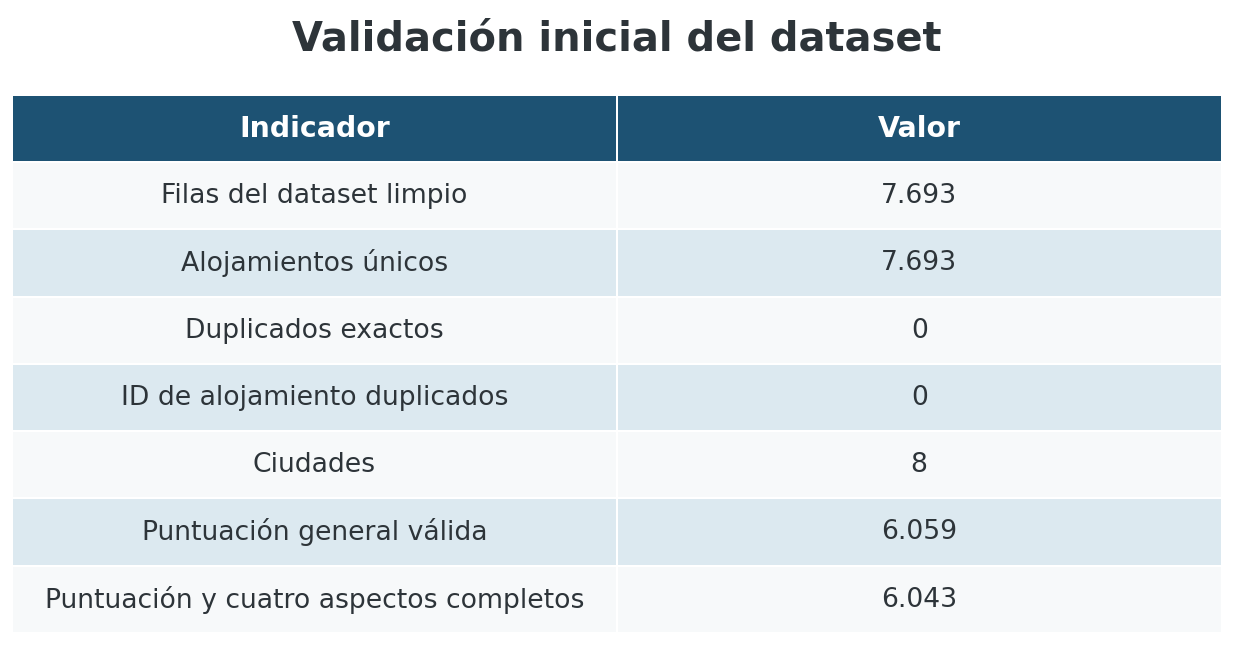

In [5]:
complete_columns = [
    "rating_general_100",
    *ASPECT_COLUMNS_100.values(),
]

df_valid_rating = df.dropna(
    subset=["rating_general_100"]
).copy()

df_complete = df.dropna(
    subset=complete_columns
).copy()

quality_summary = pd.DataFrame(
    {
        "Indicador": [
            "Filas del dataset limpio",
            "Alojamientos únicos",
            "Duplicados exactos",
            "ID de alojamiento duplicados",
            "Ciudades",
            "Puntuación general válida",
            "Puntuación y cuatro aspectos completos",
        ],
        "Valor": [
            len(df),
            df["apartment_id"].nunique(),
            df.duplicated().sum(),
            df["apartment_id"].duplicated().sum(),
            df["city"].nunique(),
            len(df_valid_rating),
            len(df_complete),
        ],
    }
)

graphic_table(
    quality_summary,
    "Validación inicial del dataset",
    formats={"Valor": "{:,.0f}"},
    width=10.5,
)

### Interpretación

El dataset limpio contiene **7.693 alojamientos únicos** y no presenta valores duplicados en `apartment_id`. Por tanto, cada fila representa un alojamiento y no es necesario volver a eliminar snapshots.

La puntuación general ya está expresada en una escala de 0 a 100. 
Las puntuaciones de precisión, limpieza, check-in y comunicación, originalmente en una escala de 0 a 10, 
se multiplican por 10 para trabajar con una escala común.

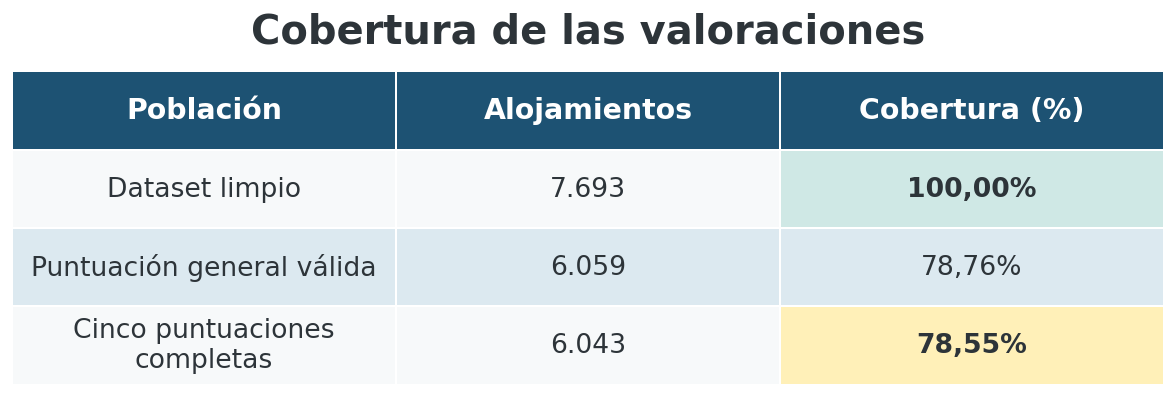

In [6]:
coverage_summary = pd.DataFrame(
    {
        "Población": [
            "Dataset limpio",
            "Puntuación general válida",
            "Cinco puntuaciones completas",
        ],
        "Alojamientos": [
            len(df),
            len(df_valid_rating),
            len(df_complete),
        ],
        "Cobertura (%)": [
            100,
            len(df_valid_rating) / len(df) * 100,
            len(df_complete) / len(df) * 100,
        ],
    }
)

graphic_table(
    coverage_summary,
    "Cobertura de las valoraciones",
    formats={
        "Alojamientos": "{:,.0f}",
        "Cobertura (%)": "{:.2f}%",
    },
    highlight_max=["Cobertura (%)"],
    highlight_min=["Cobertura (%)"],
    width=10,
)

### Interpretación

De los **7.693 alojamientos**, **6.059** tienen una puntuación general
válida y **6.043** disponen también de los cuatro aspectos completos.

Esto significa que la muestra final representa el **78,55 %** del
dataset.

La mayor parte de los casos excluidos no tiene valoración general.
Entre los alojamientos con rating válido, solo 16 presentan algún
aspecto incompleto.

No se imputan estas puntuaciones porque hacerlo podría crear
valoraciones que no fueron dadas realmente por los huéspedes.

## 3. Calidad y cobertura por ciudad

En este paso revisamos qué porcentaje de alojamientos tiene las cinco
puntuaciones completas en cada ciudad.

Esto no mide la satisfacción. Sirve para comprobar si algunas ciudades
están menos representadas en la muestra final y si sus resultados
necesitan más cautela.

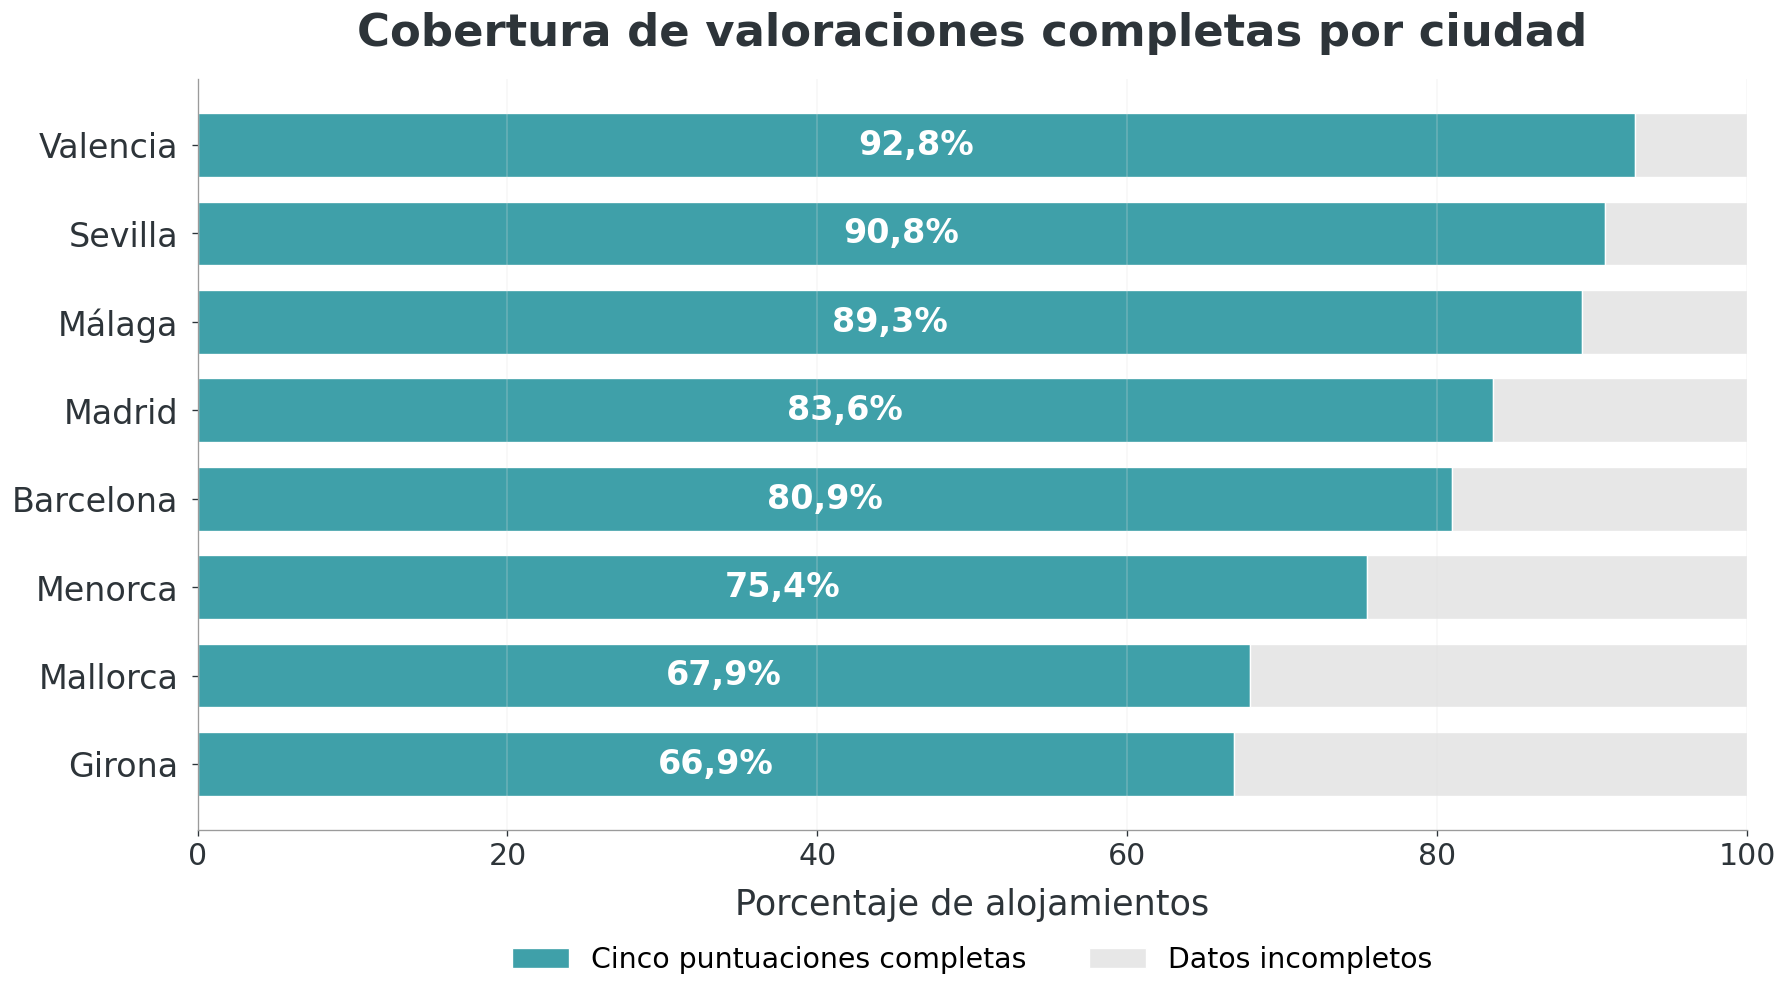

In [7]:
coverage_by_city = (
    df.groupby("city", as_index=False)
    .agg(
        Alojamientos=(
            "apartment_id",
            "nunique",
        )
    )
)

complete_by_city = (
    df_complete.groupby("city")
    .size()
    .rename("Casos_completos")
)

coverage_by_city = (
    coverage_by_city
    .set_index("city")
    .join(complete_by_city)
    .fillna({"Casos_completos": 0})
    .reset_index()
    .rename(columns={"city": "Ciudad"})
)

coverage_by_city[
    "Cobertura completa (%)"
] = (
    coverage_by_city["Casos_completos"]
    / coverage_by_city["Alojamientos"]
    * 100
)

coverage_by_city[
    "Sin datos completos (%)"
] = (
    100
    - coverage_by_city[
        "Cobertura completa (%)"
    ]
)

coverage_plot = (
    coverage_by_city
    .sort_values("Cobertura completa (%)")
    .copy()
)

fig, ax = plt.subplots(
    figsize=(15, 8.5)
)

bars_complete = ax.barh(
    coverage_plot["Ciudad"],
    coverage_plot["Cobertura completa (%)"],
    color=TEAL,height=0.72,edgecolor=WHITE,linewidth=0.8,label="Cinco puntuaciones completas",
)

ax.barh(
    coverage_plot["Ciudad"],
    coverage_plot["Sin datos completos (%)"],
    left=coverage_plot["Cobertura completa (%)"],
    color=LIGHT_GREY,height=0.72,edgecolor=WHITE,linewidth=0.8,label="Datos incompletos",
)

for bar, value in zip(
    bars_complete,
    coverage_plot["Cobertura completa (%)"],
):
    value_text = f"{format_es(value, 1)}%"

    ax.text(
        value / 2,
        bar.get_y() + bar.get_height() / 2,
        value_text,ha="center",va="center",color=WHITE,fontsize=20,fontweight="bold",
    )

ax.set_title(
    "Cobertura de valoraciones completas por ciudad",fontsize=27,fontweight="bold",color=DARK,pad=20,
)

ax.set_xlabel(
    "Porcentaje de alojamientos",fontsize=21,labelpad=10,
)

ax.set_ylabel("")

ax.set_xlim(0, 100)

ax.set_xticks(
    np.arange(0, 101, 20)
)

ax.tick_params(
    axis="x",labelsize=18,
)

ax.tick_params(
    axis="y",labelsize=20,pad=8,
)

ax.legend(
    frameon=False,ncol=2,loc="upper center",bbox_to_anchor=(0.5, -0.12),fontsize=17,handlelength=2,columnspacing=2.2,
)

ax.grid(
    axis="x",alpha=0.25,linewidth=1,
)

ax.grid(
    axis="y",visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.margins(y=0.05)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

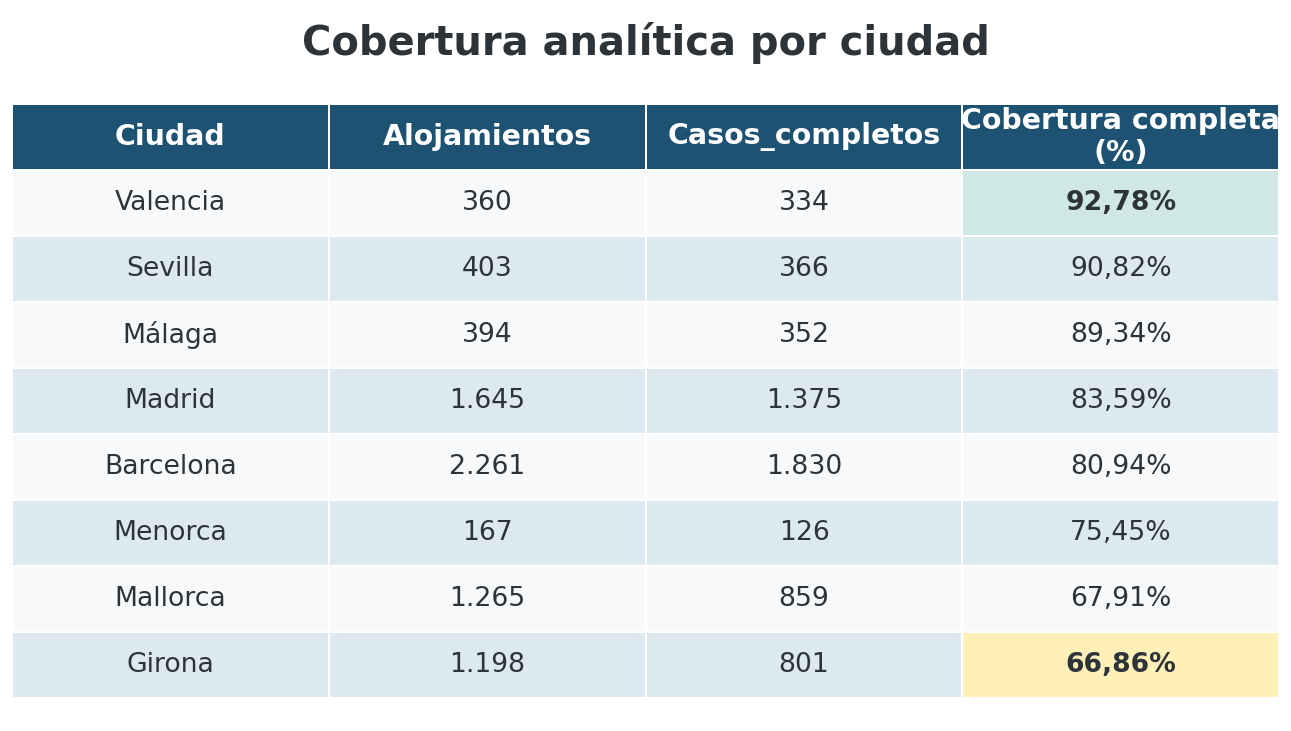

In [8]:
coverage_table = coverage_by_city[
    [
        "Ciudad",
        "Alojamientos",
        "Casos_completos",
        "Cobertura completa (%)",
    ]
].sort_values(
    "Cobertura completa (%)",
    ascending=False,
).reset_index(drop=True)

graphic_table(
    coverage_table,
    "Cobertura analítica por ciudad",
    formats={
        "Alojamientos": "{:,.0f}",
        "Casos_completos": "{:,.0f}",
        "Cobertura completa (%)": "{:.2f}%",
    },
    highlight_max=["Cobertura completa (%)"],
    highlight_min=["Cobertura completa (%)"],
    width=11,
)

### Interpretación

La cobertura no es igual en todas las ciudades.

Los porcentajes más altos se encuentran en:

- **Valencia: 92,78 %**
- **Sevilla: 90,82 %**
- **Málaga: 89,34 %**

Los porcentajes más bajos corresponden a:

- **Mallorca: 67,91 %**
- **Girona: 66,86 %**

Esto no significa que los resultados de Girona o Mallorca sean
incorrectos. Significa que representan a una parte menor de los
alojamientos de esas ciudades y deben interpretarse con más cautela.

## 4. Exploración de las puntuaciones

Antes de crear los grupos, revisamos cómo se distribuyen la puntuación
general y los cuatro aspectos.

En esta parte buscamos:

- La concentración de puntuaciones altas.
- La presencia de efecto techo.
- Los valores de Q1 y Q3.
- La relación inicial entre cada aspecto y la puntuación general.

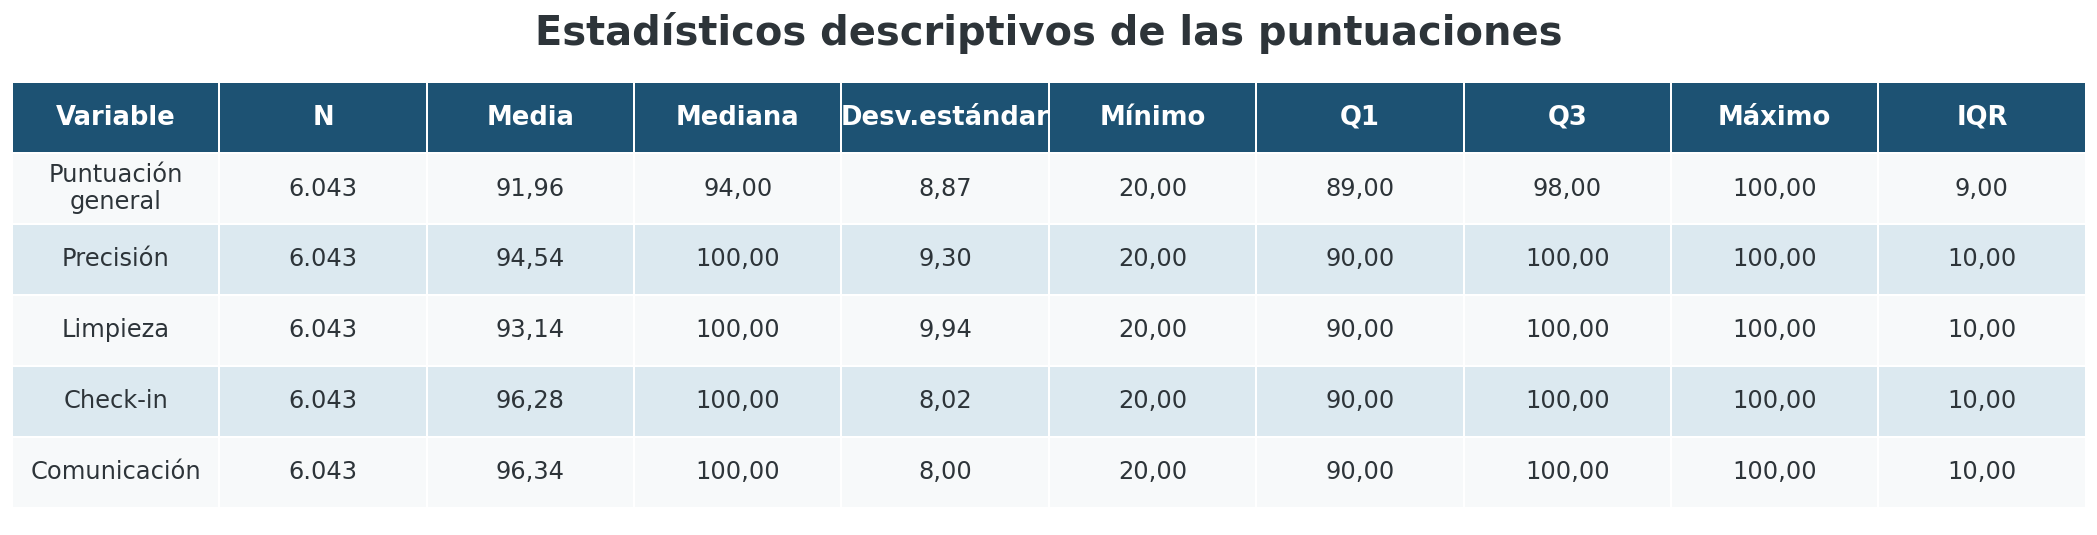

In [9]:
score_columns = {
    "rating_general_100": "Puntuación general",
    **{
        column: aspect
        for aspect, column in ASPECT_COLUMNS_100.items()
    },
}

score_summary = (
    df_complete[list(score_columns)]
    .rename(columns=score_columns)
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "Variable"})
)
score_summary["IQR"] = score_summary["75%"] - score_summary["25%"]

score_table = score_summary[
    [
        "Variable",
        "count",
        "mean",
        "50%",
        "std",
        "min",
        "25%",
        "75%",
        "max",
        "IQR",
    ]
].rename(
    columns={
        "count": "N",
        "mean": "Media",
        "50%": "Mediana",
        "std": "Desv.estándar",
        "min": "Mínimo",
        "25%": "Q1",
        "75%": "Q3",
        "max": "Máximo",
    }
)

graphic_table(
    score_table,
    "Estadísticos descriptivos de las puntuaciones",
    formats={
        "N": "{:,.0f}",
        "Media": "{:.2f}",
        "Mediana": "{:.2f}",
        "Desv.estándar": "{:.2f}",
        "Mínimo": "{:.2f}",
        "Q1": "{:.2f}",
        "Q3": "{:.2f}",
        "Máximo": "{:.2f}",
        "IQR": "{:.2f}",
    },
    width=18,
    font_size=14.5,
)

### Interpretación

La puntuación general tiene una media de **91,96** y una mediana de
**94**, por lo que la mayoría de los alojamientos recibe valoraciones
altas.

Los cuatro aspectos tienen una mediana de **100**. Esto muestra un
efecto techo: muchos alojamientos reciben la puntuación máxima y las
medianas tienen poca capacidad para diferenciarlos.

Entre los cuatro aspectos:

- **Limpieza** presenta la media más baja: **93,14**.
- **Precisión** tiene una media de **94,54**.
- **Comunicación** y **check-in** presentan las medias más altas.

Por este motivo, además de las medianas, analizaremos las medias,
las distribuciones y el tamaño del efecto.

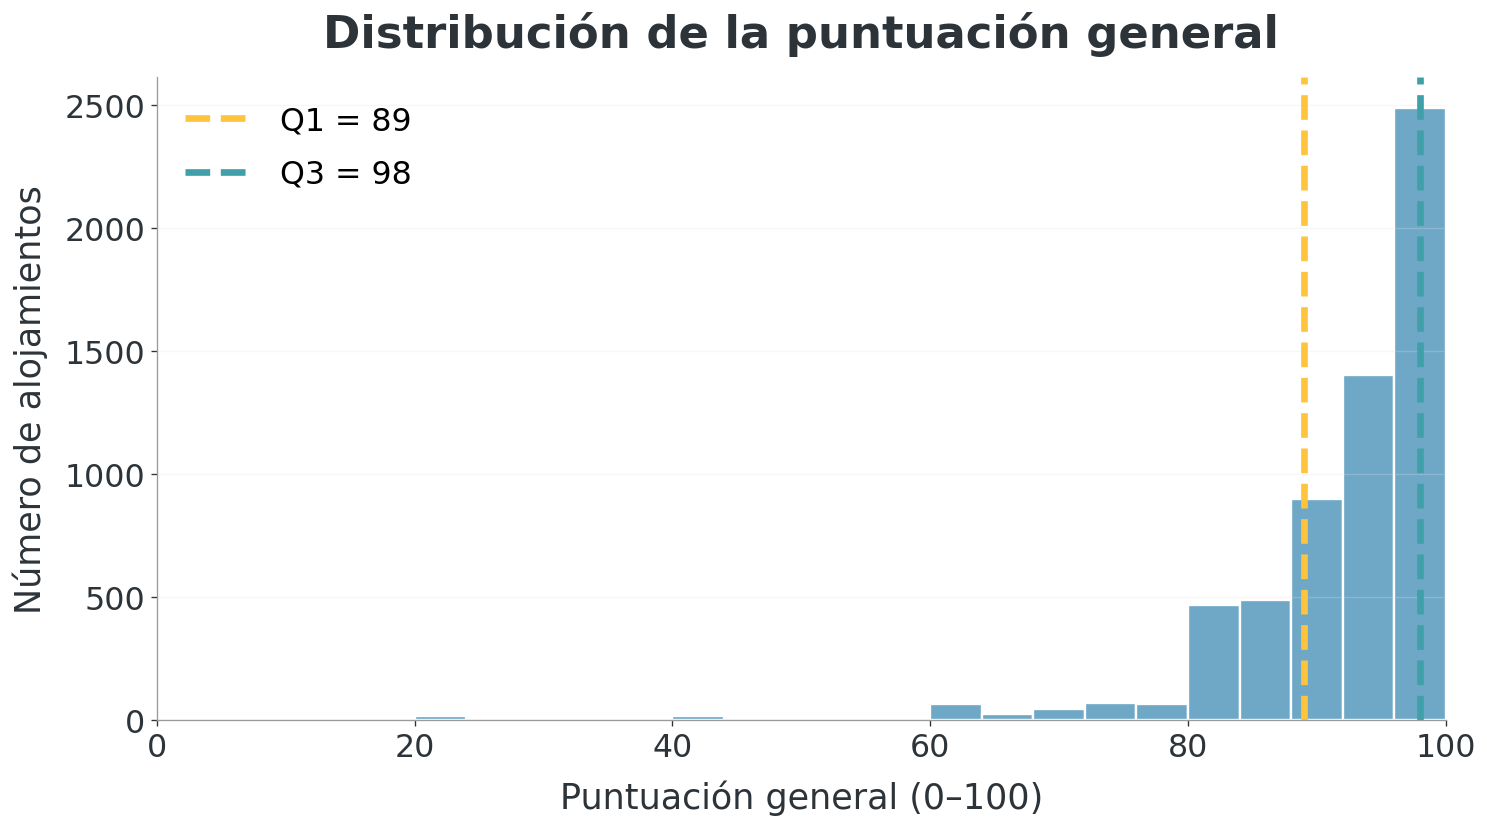

In [10]:
q1_all = df_valid_rating[
    "rating_general_100"
].quantile(0.25)

q3_all = df_valid_rating[
    "rating_general_100"
].quantile(0.75)

fig, ax = plt.subplots(figsize=(12.5, 7))

ax.hist(
    df_valid_rating["rating_general_100"],bins=20,color=MID_BLUE,edgecolor=WHITE,linewidth=1.4,
)

ax.axvline(
    q1_all,color=YELLOW,linestyle="--",linewidth=4,label=f"Q1 = {q1_all:.0f}",
)

ax.axvline(
    q3_all,color=TEAL,linestyle="--",linewidth=4,label=f"Q3 = {q3_all:.0f}",
)

ax.set_xlim(0, 100)

ax.set_title(
    "Distribución de la puntuación general",fontsize=27,fontweight="bold",pad=18,
)

ax.set_xlabel(
    "Puntuación general (0–100)",fontsize=21,labelpad=10,
)

ax.set_ylabel(
    "Número de alojamientos",fontsize=21,labelpad=10,
)

# Tamaño de los números de ambos ejes
ax.tick_params(
    axis="x",labelsize=19,
)

ax.tick_params(
    axis="y",labelsize=19,
)

ax.set_xticks(
    np.arange(0, 101, 20)
)

ax.legend(
    frameon=False,loc="upper left",fontsize=19,handlelength=2.2,labelspacing=0.7,
)

ax.grid(
    axis="y",alpha=0.25,
)

ax.grid(
    axis="x",visible=False,
)

plt.tight_layout()
plt.show()

### Interpretación

La distribución de la puntuación general está muy concentrada en la
parte alta de la escala, aunque también hay algunos alojamientos con
puntuaciones bastante más bajas.

Los puntos de corte son:

- **Q1 = 89**
- **Q3 = 98**

También se observan muchos empates en estos valores. Por eso, al
incluir los alojamientos con puntuación igual a Q1 o Q3, los grupos
pueden contener algo más del 25 % de los casos.

### Correlación exploratoria

Como primera revisión, calculamos la correlación de Spearman entre
la puntuación general y cada uno de los cuatro aspectos.

Se utiliza Spearman porque las puntuaciones están concentradas en
valores altos, presentan empates y no conviene asumir una distribución
normal.

Esta parte es complementaria. La respuesta principal se obtendrá
comparando directamente los alojamientos mejor y peor valorados.

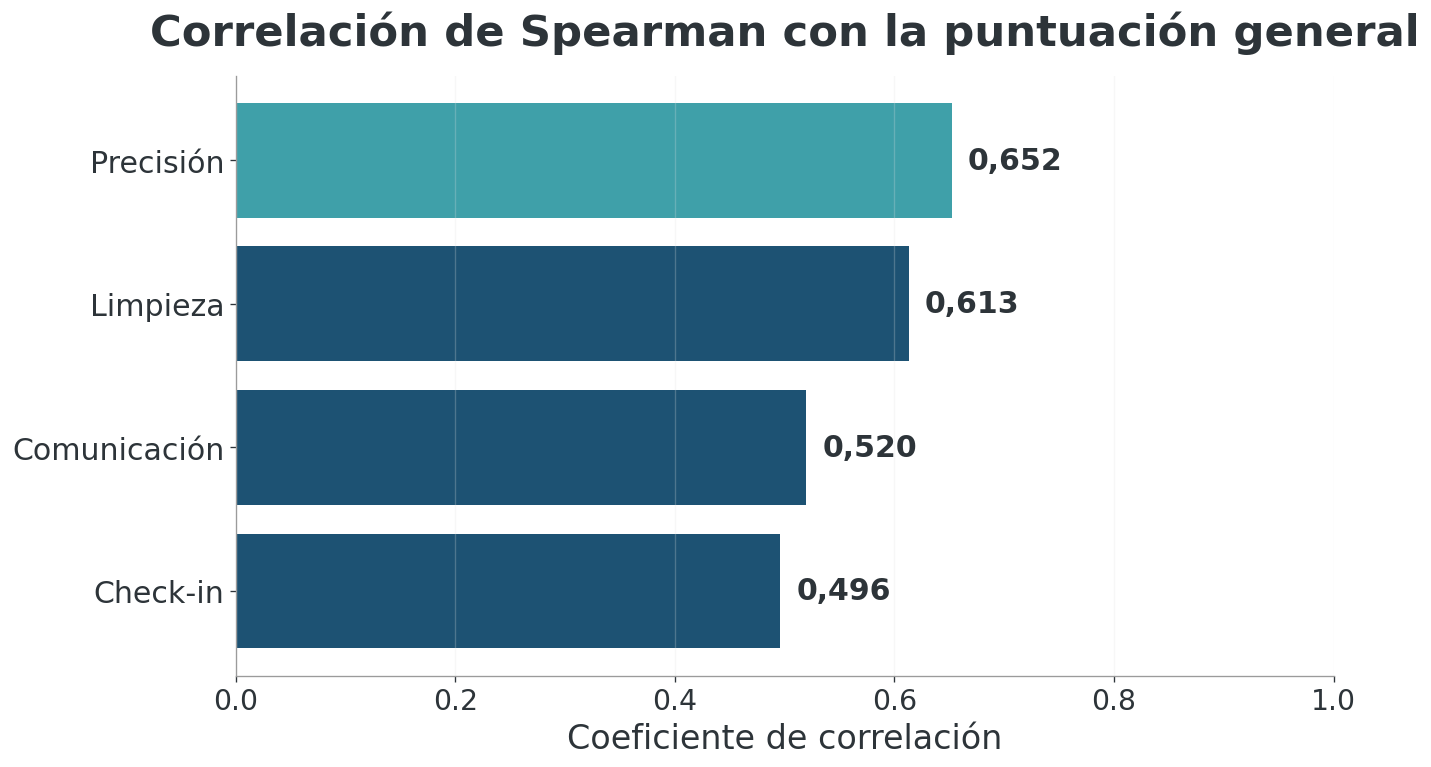

In [11]:
correlation_data = df_complete[list(score_columns)].rename(
    columns=score_columns
)

rating_correlations = (
    correlation_data.corr(method="spearman")["Puntuación general"]
    .drop("Puntuación general")
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))
colors = [
    TEAL if value == rating_correlations.max() else NAVY
    for value in rating_correlations
]

bars = ax.barh(
    rating_correlations.index,
    rating_correlations.values,
    color=colors,
)

for bar, value in zip(bars, rating_correlations.values):
    ax.text(
        value + 0.015,
        bar.get_y() + bar.get_height() / 2,
        format_es(value, 3),
        va="center",
        fontsize=18,
        fontweight="bold",
        color=DARK,
    )

ax.set_title(
    "Correlación de Spearman con la puntuación general",
    fontsize=26,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Coeficiente de correlación", fontsize=20)
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.tick_params(axis="x", labelsize=17)
ax.tick_params(axis="y", labelsize=18)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

Los cuatro aspectos tienen una relación positiva con la puntuación
general.

Los resultados son:

- **Precisión:** ρ = 0,652
- **Limpieza:** ρ = 0,613
- **Comunicación:** ρ = 0,520
- **Check-in:** ρ = 0,496

Precisión muestra la relación más fuerte, seguida de limpieza.

Esto no significa que precisión sea la causa de una mejor valoración.
Solo indica que, dentro de este dataset, ambas puntuaciones tienden
a aumentar juntas.

## 5. Segmentación mediante cuartiles

Para comparar los alojamientos mejor y peor valorados, se utilizan
los cuartiles de la puntuación general:

- **Peor valorados:** puntuación general menor o igual a Q1.
- **Mejor valorados:** puntuación general mayor o igual a Q3.
- **Intermedios:** alojamientos situados entre ambos puntos de corte.

Los puntos de corte Q1 y Q3 se calculan sobre todos los alojamientos
con una puntuación general válida. Posteriormente, estos puntos de
corte se aplican a la muestra analítica formada por los alojamientos
que tienen la puntuación general y los cuatro aspectos completos.

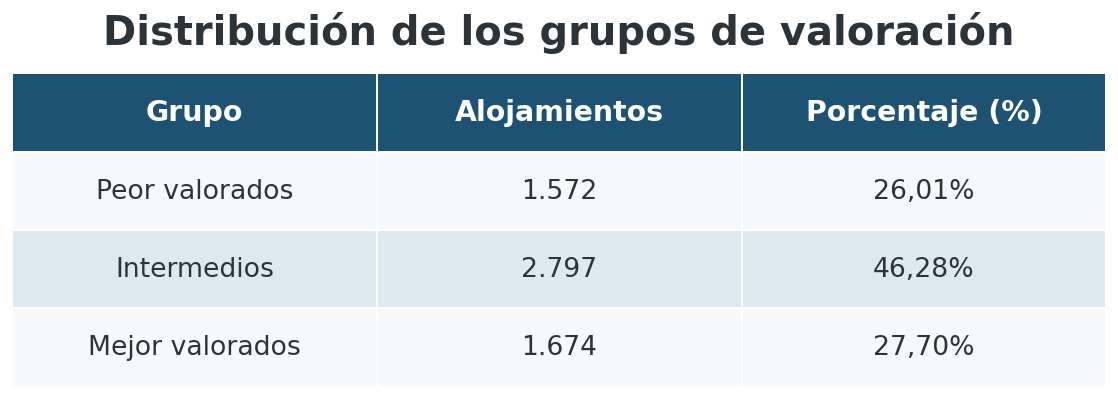

Percentil 25 (Q1): 89.0
Percentil 75 (Q3): 98.0


In [12]:
q1 = q1_all
q3 = q3_all

df_complete["grupo_valoracion"] = np.select(
    [
        df_complete["rating_general_100"] <= q1,
        df_complete["rating_general_100"] >= q3,
    ],
    [
        "Peor valorados",
        "Mejor valorados",
    ],
    default="Intermedios",
)

group_counts = (
    df_complete["grupo_valoracion"]
    .value_counts()
    .reindex(
        [
            "Peor valorados",
            "Intermedios",
            "Mejor valorados",
        ]
    )
    .rename_axis("Grupo")
    .reset_index(name="Alojamientos")
)

group_counts["Porcentaje (%)"] = (
    group_counts["Alojamientos"]
    / len(df_complete)
    * 100
)

graphic_table(
    group_counts,
    "Distribución de los grupos de valoración",
    formats={
        "Alojamientos": "{:,.0f}",
        "Porcentaje (%)": "{:.2f}%",
    },
    width=9.5,
)

print(f"Percentil 25 (Q1): {q1:.1f}")
print(f"Percentil 75 (Q3): {q3:.1f}")

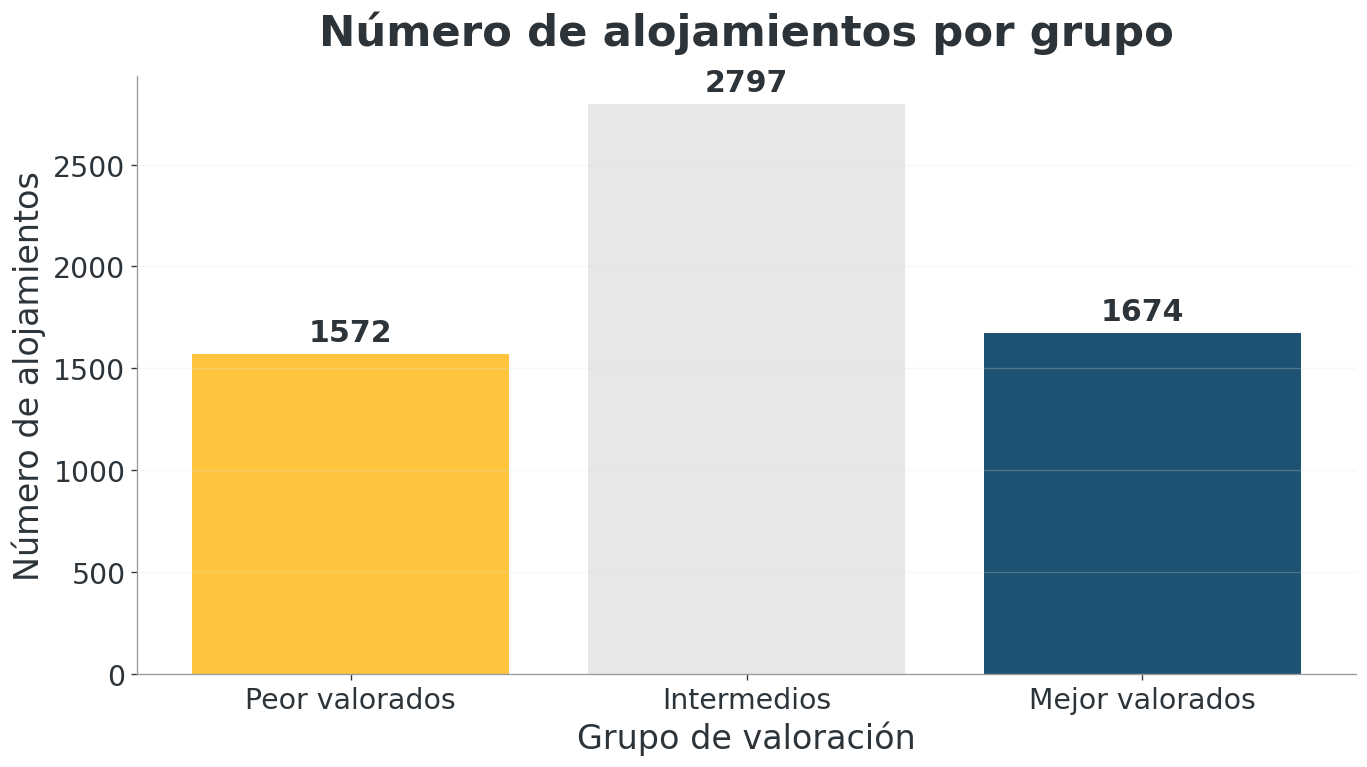

In [13]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))

bars = ax.bar(
    group_counts["Grupo"],
    group_counts["Alojamientos"],
    color=[
        GROUP_COLORS[group]
        for group in group_counts["Grupo"]
    ],
)

ax.set_title(
    "Número de alojamientos por grupo",
    fontsize=26,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Grupo de valoración", fontsize=20)
ax.set_ylabel("Número de alojamientos", fontsize=20)
ax.tick_params(axis="x", labelsize=17)
ax.tick_params(axis="y", labelsize=17)

add_vertical_labels(
    ax,
    decimals=0,
    fontsize=18,
)

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


### Interpretación

Con **Q1 = 89** y **Q3 = 98** se obtienen:

- **1.572 alojamientos peor valorados**
- **1.674 alojamientos mejor valorados**
- **2.797 alojamientos intermedios**

Los dos grupos principales tienen tamaños bastante parecidos, lo que
facilita su comparación.

Debido a los empates en los puntos de corte, los grupos extremos
representan algo más del 50 % de la muestra. El grupo intermedio
representa el **46,28 %**.

In [14]:
GROUP_ORDER = [
    "Peor valorados",
    "Mejor valorados",
]

df_extremes = df_complete[
    df_complete["grupo_valoracion"].isin(
        GROUP_ORDER
    )
].copy()

print(
    "Alojamientos incluidos en la comparación: "
    f"{len(df_extremes):,}"
)

Alojamientos incluidos en la comparación: 3,246


### Muestra utilizada en la comparación

La comparación principal se realiza con **3.246 alojamientos**:

- **1.572 peor valorados**
- **1.674 mejor valorados**

Los alojamientos del grupo intermedio no se utilizan en esta parte
del análisis.

## 6. Comparación descriptiva entre los grupos

Ahora comparamos precisión, limpieza, check-in y comunicación entre
los alojamientos mejor y peor valorados.

Primero revisamos la forma de las distribuciones y después calculamos
las medias, medianas y diferencias entre los dos grupos.

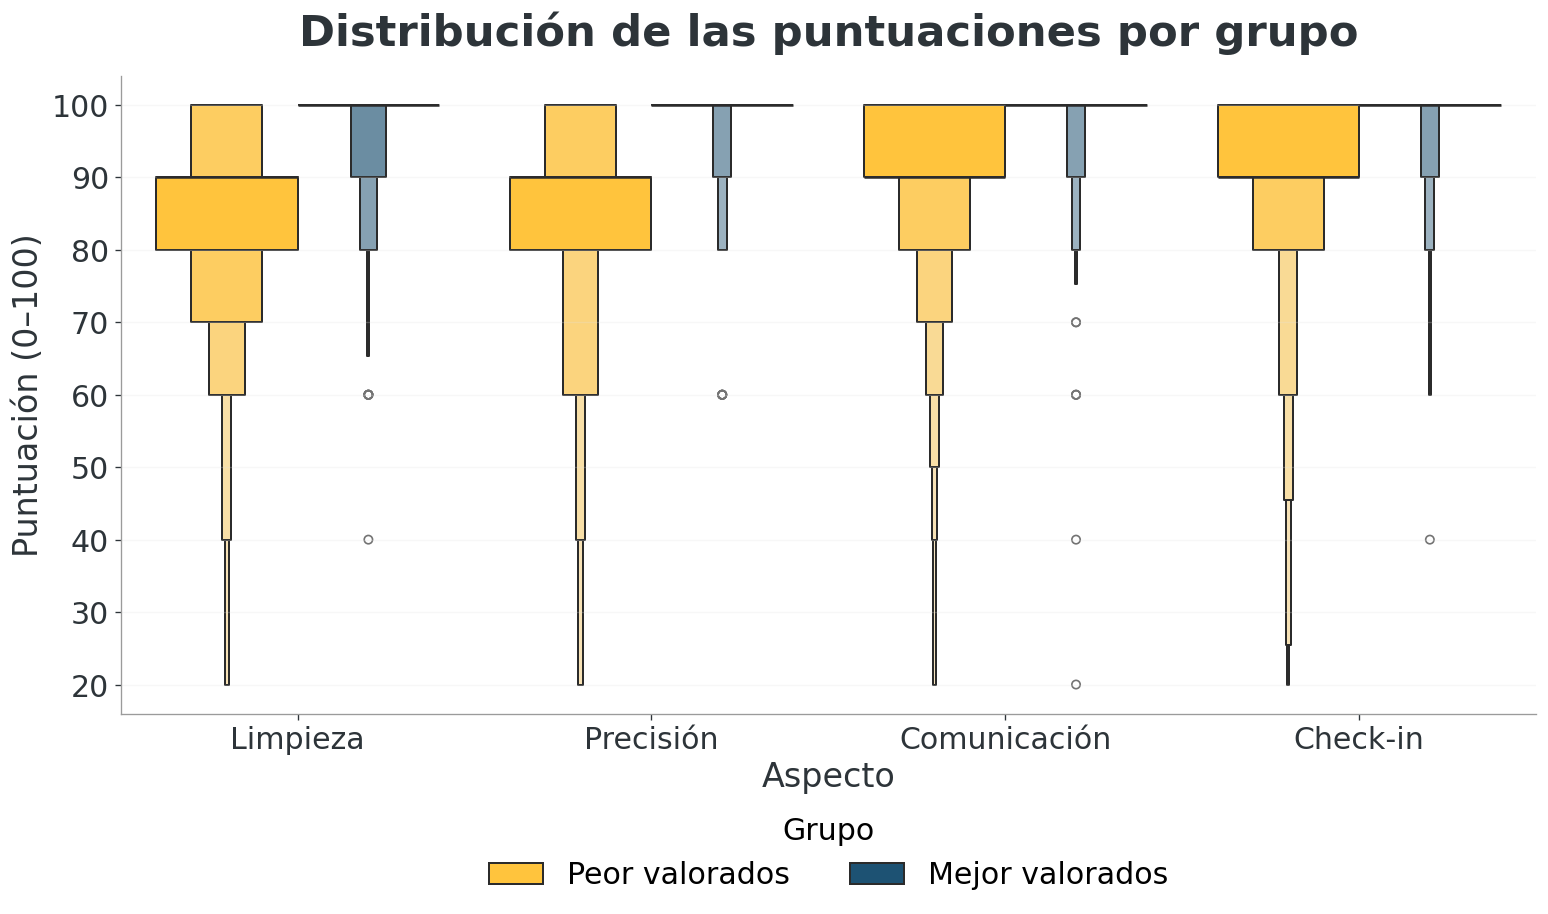

In [15]:
long_data = df_extremes.melt(
    id_vars="grupo_valoracion",
    value_vars=list(ASPECT_COLUMNS_100.values()),
    var_name="Variable",
    value_name="Puntuación",
)

aspect_labels = {
    column: aspect
    for aspect, column in ASPECT_COLUMNS_100.items()
}

long_data["Aspecto"] = pd.Categorical(
    long_data["Variable"].map(aspect_labels),
    categories=ASPECT_ORDER,
    ordered=True,
)

fig, ax = plt.subplots(figsize=(13, 7.5))

sns.boxenplot(
    data=long_data,
    x="Aspecto",
    y="Puntuación",
    hue="grupo_valoracion",
    order=ASPECT_ORDER,
    hue_order=GROUP_ORDER,
    palette={
        "Peor valorados": YELLOW,
        "Mejor valorados": NAVY,
    },
    linewidth=1.2,
    saturation=1,
    ax=ax,
)

ax.set_title(
    "Distribución de las puntuaciones por grupo",
    fontsize=26,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Aspecto", fontsize=20)
ax.set_ylabel("Puntuación (0–100)", fontsize=20)
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)
ax.legend(
    title="Grupo",
    title_fontsize=18,
    fontsize=18,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    handlelength=1.8,
    columnspacing=2.0,
)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

### Interpretación

Los alojamientos mejor valorados están muy concentrados cerca de 100
y presentan poca variación.

En el grupo peor valorado las puntuaciones están más dispersas. La
separación entre los dos grupos se ve especialmente en limpieza y
precisión.

Comunicación y check-in también muestran diferencias, pero mantienen
puntuaciones relativamente altas incluso dentro del grupo peor
valorado.

Los valores bajos se mantienen porque están dentro del rango válido
y pueden representar experiencias reales. No se eliminan valores
atípicos de forma automática.

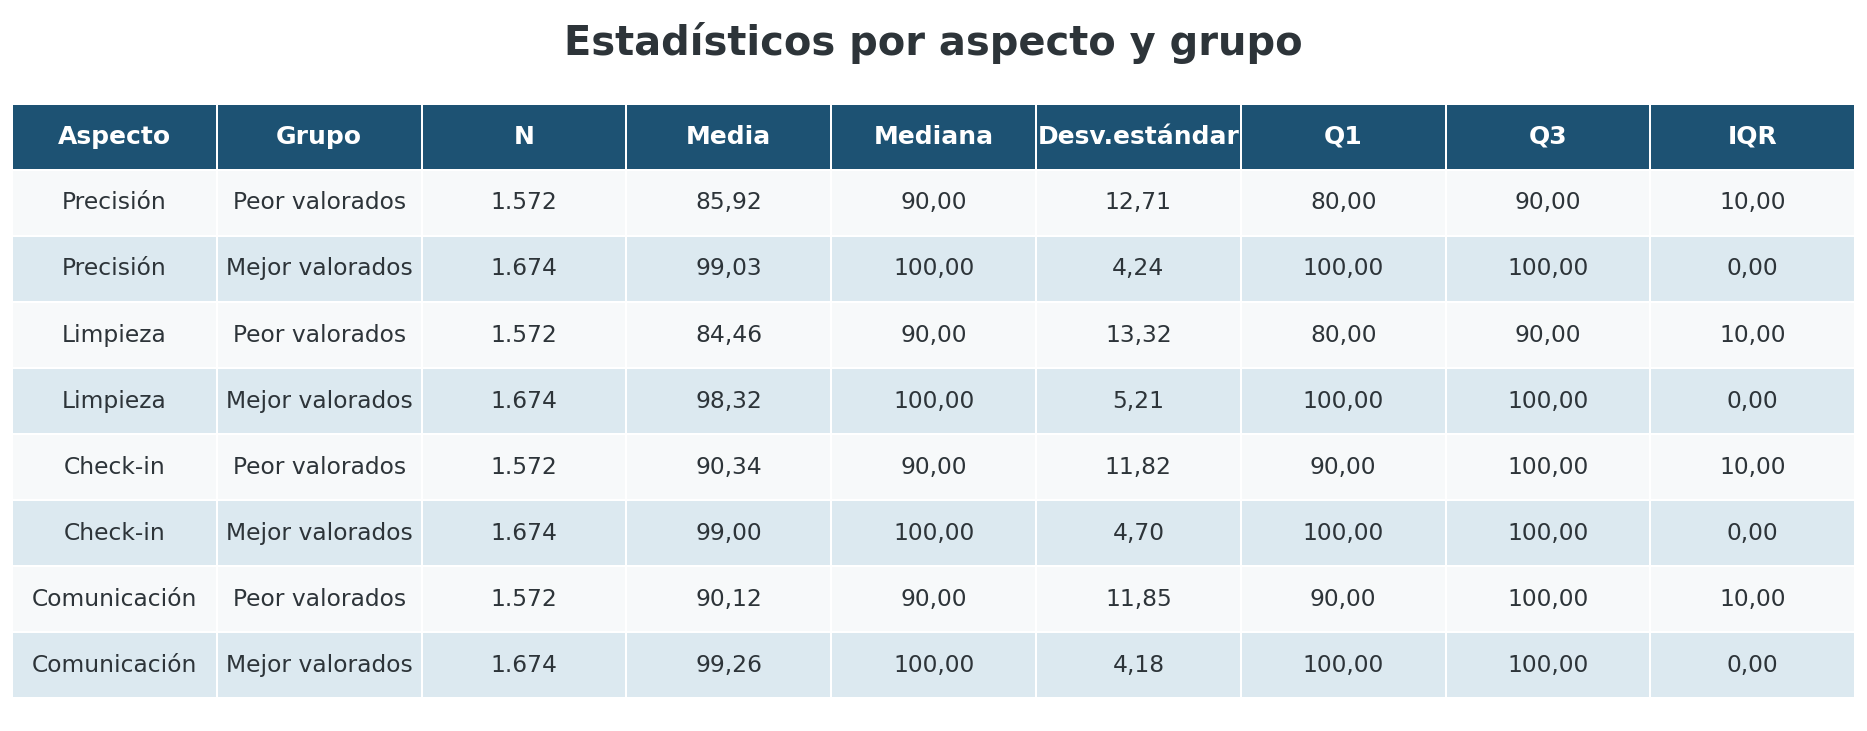

In [16]:
descriptive_rows = []

for aspect, column in ASPECT_COLUMNS_100.items():
    for group in GROUP_ORDER:
        values = df_extremes.loc[
            df_extremes["grupo_valoracion"] == group,
            column,
        ]
        q1_value = values.quantile(0.25)
        q3_value = values.quantile(0.75)

        descriptive_rows.append(
            {
                "Aspecto": aspect,
                "Grupo": group,
                "N": len(values),
                "Media": values.mean(),
                "Mediana": values.median(),
                "Desv.estándar": values.std(),
                "Q1": q1_value,
                "Q3": q3_value,
                "IQR": q3_value - q1_value,
            }
        )

descriptive_results = pd.DataFrame(descriptive_rows)

graphic_table(
    descriptive_results,
    "Estadísticos por aspecto y grupo",
    formats={
        "N": "{:,.0f}",
        "Media": "{:.2f}",
        "Mediana": "{:.2f}",
        "Desv.estándar": "{:.2f}",
        "Q1": "{:.2f}",
        "Q3": "{:.2f}",
        "IQR": "{:.2f}",
    },
    width=16,
    font_size=14,
)

### Interpretación

Los alojamientos peor valorados tienen medias más bajas y una mayor
dispersión en los cuatro aspectos.

En el grupo mejor valorado, la mediana es 100 y el rango
intercuartílico es 0 en todos los aspectos. Esto se debe a que una
parte muy grande de las puntuaciones está concentrada en el máximo.

Estas distribuciones no son normales y contienen muchos empates.
Por eso utilizaremos una prueba no paramétrica para validar las
diferencias.

### Diferencias medias entre los grupos

Para responder directamente a la pregunta de negocio, calculamos la
diferencia entre la media de los alojamientos mejor valorados y la
media de los peor valorados.

Después ordenamos los cuatro aspectos desde la mayor hasta la menor
diferencia.

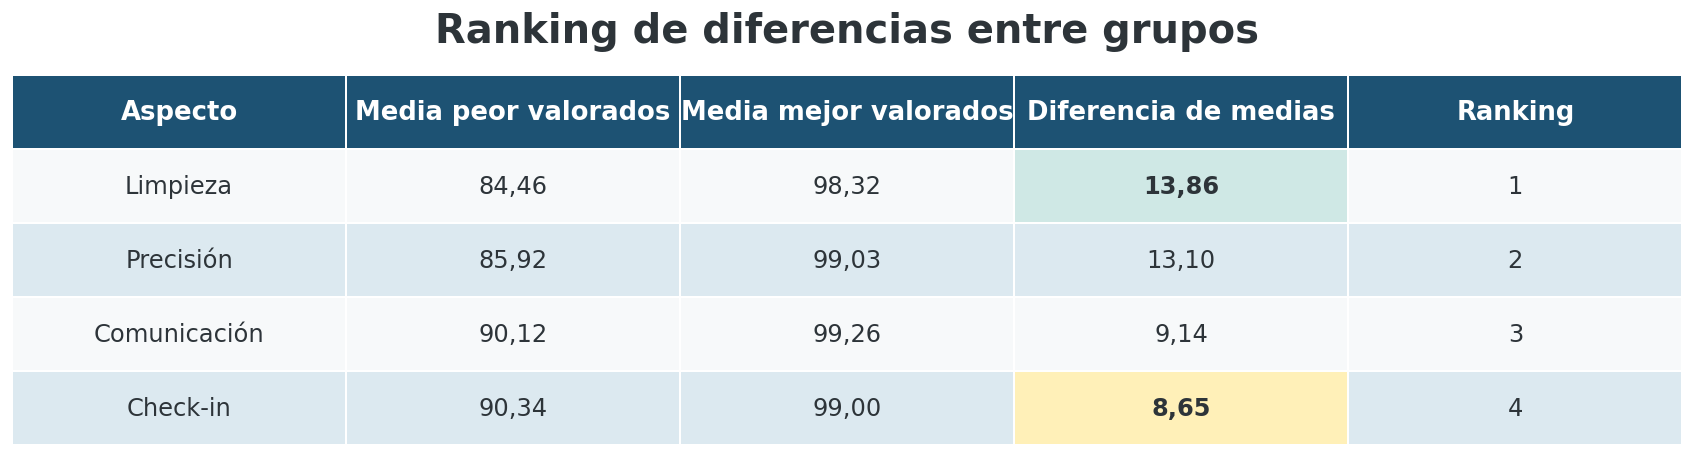

In [17]:
mean_table = descriptive_results.pivot(
    index="Aspecto",
    columns="Grupo",
    values="Media",
).loc[list(ASPECT_COLUMNS_100)]

median_table = descriptive_results.pivot(
    index="Aspecto",
    columns="Grupo",
    values="Mediana",
).loc[list(ASPECT_COLUMNS_100)]

gap_results = pd.DataFrame(
    {
        "Media mejor valorados": mean_table["Mejor valorados"],
        "Media peor valorados": mean_table["Peor valorados"],
        "Diferencia de medias": (
            mean_table["Mejor valorados"]
            - mean_table["Peor valorados"]
        ),
        "Mediana mejor valorados": median_table["Mejor valorados"],
        "Mediana peor valorados": median_table["Peor valorados"],
        "Diferencia de medianas": (
            median_table["Mejor valorados"]
            - median_table["Peor valorados"]
        ),
    }
)

gap_results["Ranking"] = (
    gap_results["Diferencia de medias"]
    .rank(method="min", ascending=False)
    .astype(int)
)

gap_results = (
    gap_results
    .sort_values("Diferencia de medias", ascending=False)
    .reset_index()
)

gap_display = gap_results[
    [
        "Aspecto",
        "Media peor valorados",
        "Media mejor valorados",
        "Diferencia de medias",
        "Ranking",
    ]
]

graphic_table(
    gap_display,
    "Ranking de diferencias entre grupos",
    formats={
        "Media peor valorados": "{:.2f}",
        "Media mejor valorados": "{:.2f}",
        "Diferencia de medias": "{:.2f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=["Diferencia de medias"],
    highlight_min=["Diferencia de medias"],
    width=14.5,
)

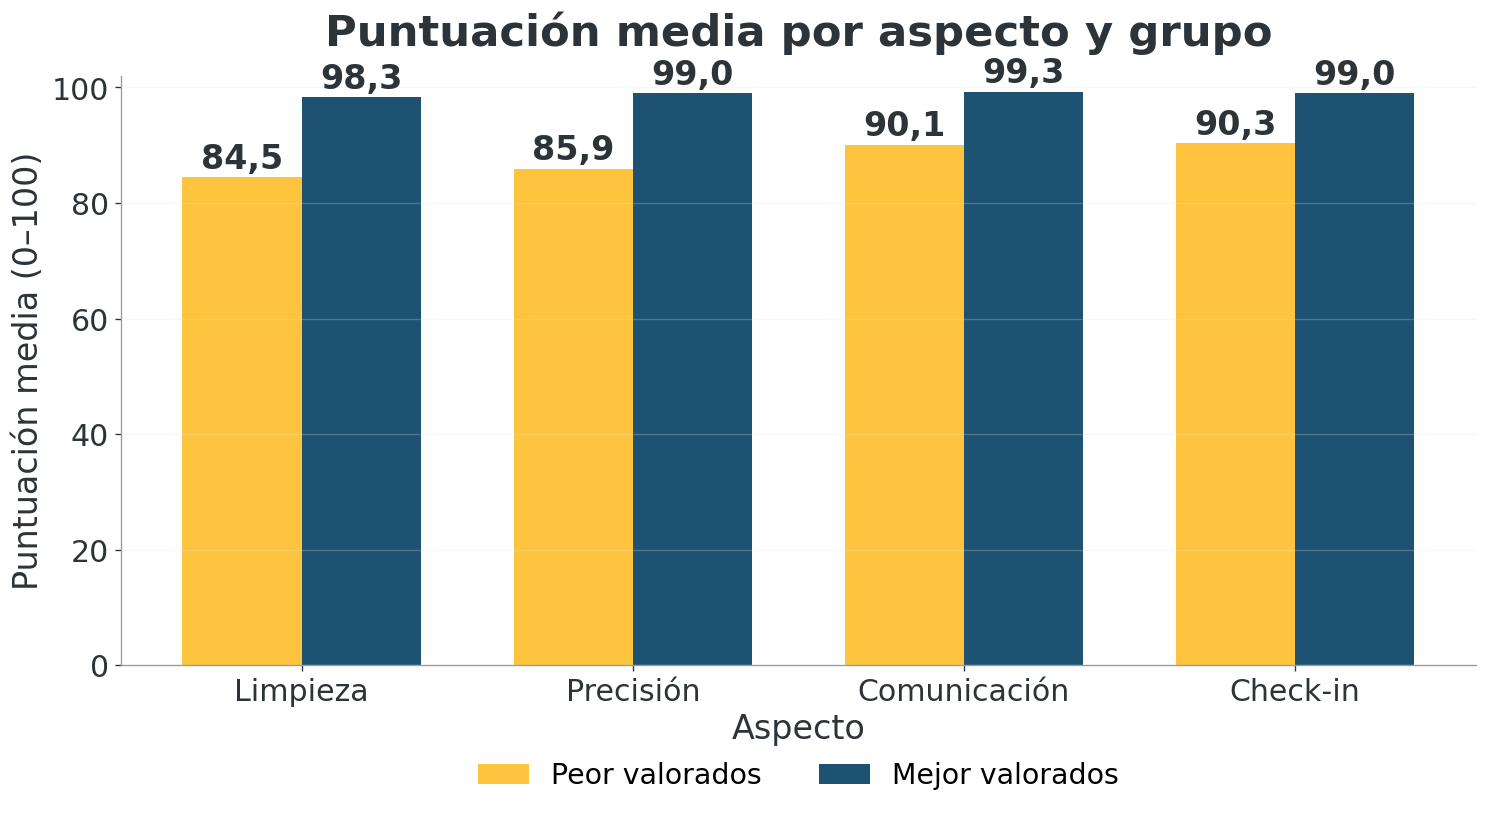

In [18]:
mean_chart = gap_results.set_index("Aspecto")[[
    "Media peor valorados",
    "Media mejor valorados",
]]

x = np.arange(len(mean_chart))
bar_width = 0.36
fig, ax = plt.subplots(figsize=(12.5, 7))

bars_worst = ax.bar(
    x - bar_width / 2,
    mean_chart["Media peor valorados"],
    width=bar_width,
    color=YELLOW,
    label="Peor valorados",
)
bars_best = ax.bar(
    x + bar_width / 2,
    mean_chart["Media mejor valorados"],
    width=bar_width,
    color=NAVY,
    label="Mejor valorados",
)

ax.set(
    title="Puntuación media por aspecto y grupo",
    xlabel="Aspecto",
    ylabel="Puntuación media (0–100)",
    ylim=(0, 102),
)
ax.set_xticks(x, mean_chart.index)
ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)
ax.set_title(
    "Puntuación media por aspecto y grupo",
    fontsize=26,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Aspecto", fontsize=20)
ax.set_ylabel("Puntuación media (0–100)", fontsize=20)
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    fontsize=17,
    columnspacing=2.0,
    handlelength=1.8,
)

for bars in (bars_worst, bars_best):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.35,
            format_es(height, 1),
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color=DARK,
        )

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

### Lectura de las medias

En los cuatro aspectos, los alojamientos mejor valorados presentan
medias cercanas a 100.

La mayor separación visual aparece en limpieza y precisión. Para
comparar estas diferencias con más claridad, el siguiente gráfico
muestra directamente el gap de cada aspecto.

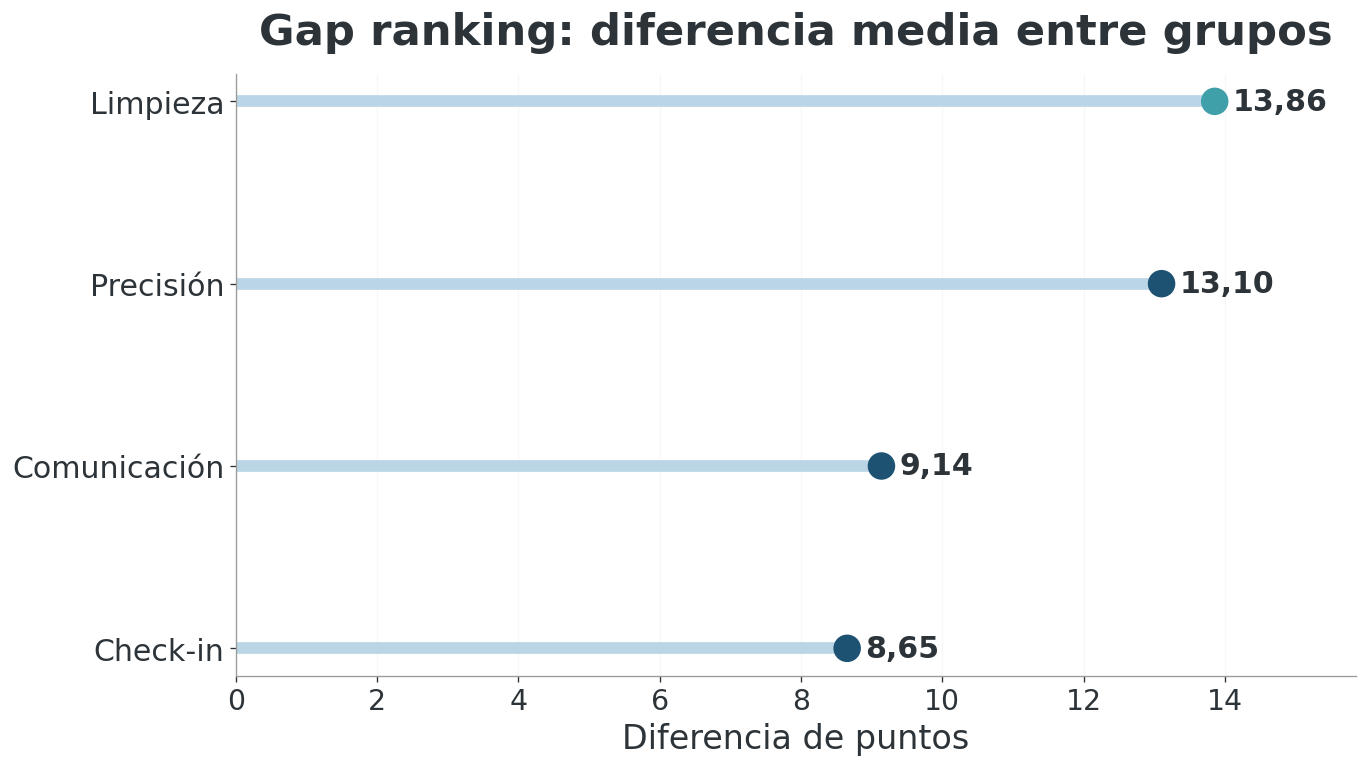

In [19]:
gap_plot = gap_results[[
    "Aspecto",
    "Diferencia de medias",
]].sort_values("Diferencia de medias")

y_positions = np.arange(len(gap_plot))
fig, ax = plt.subplots(figsize=(11.5, 6.5))

ax.hlines(
    y_positions,
    xmin=0,
    xmax=gap_plot["Diferencia de medias"],
    color=LIGHT_BLUE,
    linewidth=7,
)
ax.scatter(
    gap_plot["Diferencia de medias"],
    y_positions,
    s=240,
    color=[
        TEAL if aspect == gap_results.iloc[0]["Aspecto"] else NAVY
        for aspect in gap_plot["Aspecto"]
    ],
    zorder=3,
)

for y_position, value in zip(
    y_positions,
    gap_plot["Diferencia de medias"],
):
    ax.text(
        value + 0.25,
        y_position,
        format_es(value, 2),
        va="center",
        fontsize=18,
        fontweight="bold",
        color=DARK,
    )

ax.set_yticks(y_positions, gap_plot["Aspecto"])
ax.tick_params(axis="y", labelsize=18)
ax.set_title(
    "Gap ranking: diferencia media entre grupos",
    fontsize=26,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("Diferencia de puntos", fontsize=20)
ax.set_ylabel("")
ax.set_xlim(0, gap_plot["Diferencia de medias"].max() + 2)
ax.tick_params(axis="x", labelsize=17)
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()

### Interpretación

**Limpieza** presenta la mayor diferencia media entre los dos grupos,
con **13,86 puntos**.

El orden completo es:

1. **Limpieza:** 13,86 puntos.
2. **Precisión:** 13,10 puntos.
3. **Comunicación:** 9,14 puntos.
4. **Check-in:** 8,65 puntos.

Las diferencias de medianas son de 10 puntos en los cuatro aspectos.
Esto ocurre por el efecto techo y no permite crear un ranking claro.

Según la diferencia media, limpieza es el aspecto con mayor margen
de mejora.

## 7. Mann–Whitney U y tamaño del efecto

Para comprobar si las diferencias entre los grupos son consistentes,
se aplica la prueba **Mann–Whitney U**.

Esta prueba es adecuada porque tenemos dos grupos independientes y
las puntuaciones presentan asimetría, muchos empates y efecto techo.

Como realizamos cuatro pruebas, los valores p se ajustan con el método
de **Holm**.

También calculamos el **delta de Cliff** para conocer la intensidad
de la diferencia:

- `|δ| < 0,147`: despreciable.
- `|δ| < 0,330`: pequeño.
- `|δ| < 0,474`: moderado.
- `|δ| ≥ 0,474`: grande.

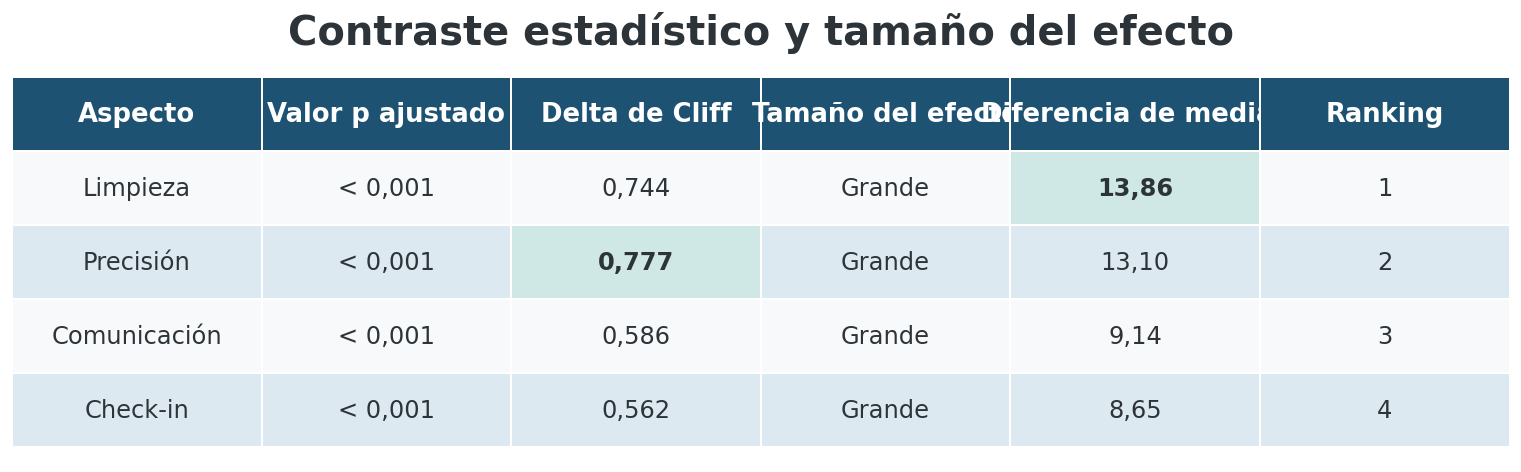

In [20]:
test_results = compare_aspects(
    df_extremes,
    "grupo_valoracion",
)[
    [
        "Aspecto",
        "U",
        "Valor p",
        "Delta de Cliff",
        "Tamaño del efecto",
    ]
].copy()

test_results["Valor p ajustado"] = holm_adjust(
    test_results["Valor p"]
)

test_results = (
    test_results
    .merge(
        gap_results[["Aspecto", "Diferencia de medias", "Ranking"]],
        on="Aspecto",
        how="left",
    )
    .sort_values("Ranking")
    .reset_index(drop=True)
)

test_display = test_results[
    [
        "Aspecto",
        "Valor p ajustado",
        "Delta de Cliff",
        "Tamaño del efecto",
        "Diferencia de medias",
        "Ranking",
    ]
].copy()

test_display["Valor p ajustado"] = (
    test_display["Valor p ajustado"].map(p_value_label)
)

graphic_table(
    test_display,
    "Contraste estadístico y tamaño del efecto",
    formats={
        "Delta de Cliff": "{:.3f}",
        "Diferencia de medias": "{:.2f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=["Delta de Cliff", "Diferencia de medias"],
    width=13,
)

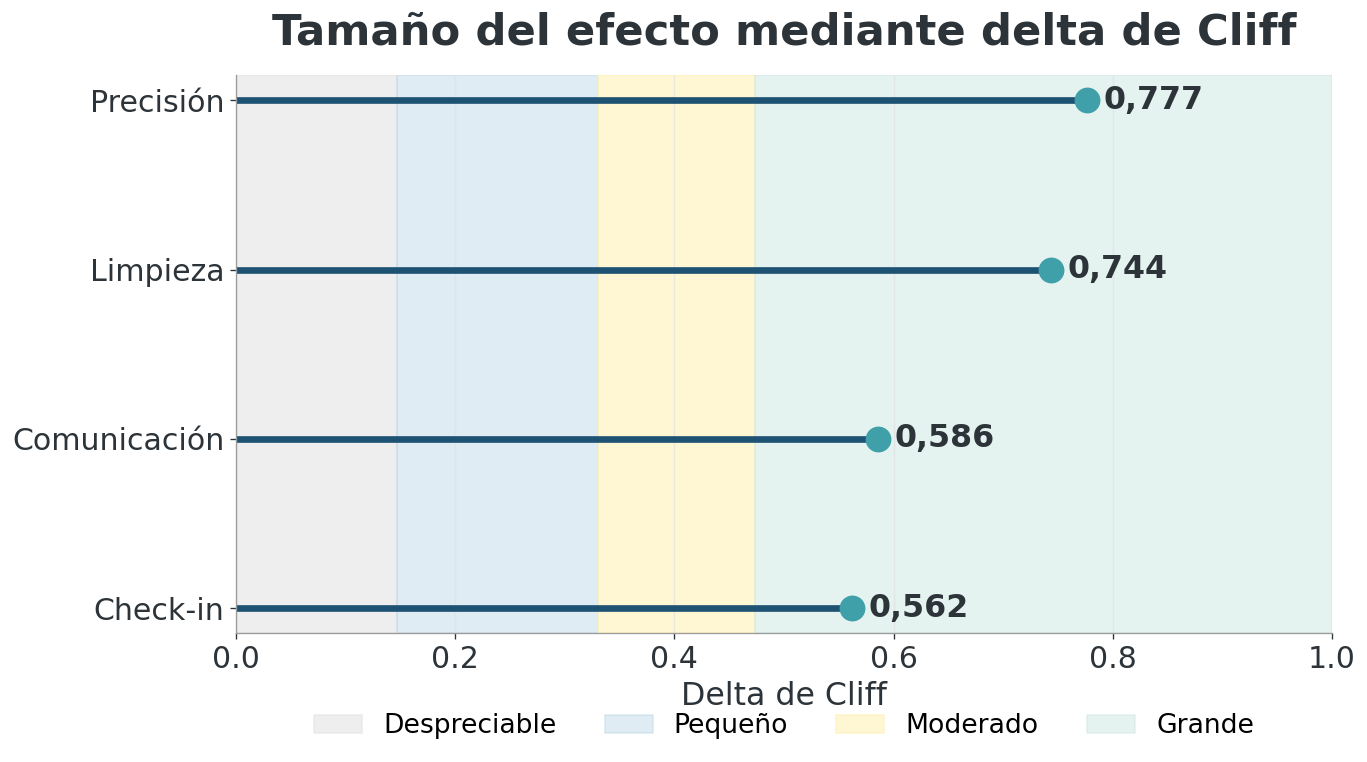

In [21]:
effect_plot = (
    test_results[
        [
            "Aspecto",
            "Delta de Cliff",
            "Tamaño del efecto",
        ]
    ]
    .copy()
    .sort_values("Delta de Cliff")
)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

y_positions = np.arange(len(effect_plot))

ax.axvspan(
    0,0.147,color=LIGHT_GREY,alpha=0.7,label="Despreciable",
)

ax.axvspan(
    0.147,0.330,color=LIGHT_BLUE,alpha=0.45,label="Pequeño",
)

ax.axvspan(
    0.330,0.474,color=LIGHT_YELLOW,alpha=0.6,label="Moderado",
)

ax.axvspan(
    0.474,1,color=LIGHT_TEAL,alpha=0.55,label="Grande",
)

ax.hlines(
    y_positions,xmin=0,xmax=effect_plot["Delta de Cliff"],color=NAVY,linewidth=4,
)

ax.scatter(
    effect_plot["Delta de Cliff"],y_positions,color=TEAL,s=210,zorder=3,
)

for y_position, value in zip(
    y_positions,
    effect_plot["Delta de Cliff"],
):
    ax.text(
        value + 0.015,
        y_position,
        format_es(value, 3),
        va="center",ha="left",fontsize=19,fontweight="bold",color=DARK,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(effect_plot["Aspecto"])

ax.set(
    title="Tamaño del efecto mediante delta de Cliff",xlabel="Delta de Cliff",ylabel="",xlim=(0, 1),
)

ax.tick_params(axis="x", labelsize=18)
ax.tick_params(axis="y", labelsize=18)

ax.grid(axis="x")
ax.grid(axis="y", visible=False)

ax.legend(
    frameon=False,ncol=4,loc="upper center",bbox_to_anchor=(0.5, -0.10),fontsize=16,handlelength=1.8,columnspacing=1.8,
)

ax.set_title(
    "Tamaño del efecto mediante delta de Cliff",fontsize=26,fontweight="bold",pad=18,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

### Interpretación

Las diferencias son estadísticamente significativas en los cuatro
aspectos después de aplicar la corrección de Holm:

`p ajustado < 0,001`

Además, los cuatro aspectos presentan un tamaño del efecto grande:

- **Precisión:** δ = 0,777
- **Limpieza:** δ = 0,744
- **Comunicación:** δ = 0,586
- **Check-in:** δ = 0,562

Aquí aparece un resultado importante:

- Limpieza tiene la mayor diferencia media.
- Precisión tiene el mayor tamaño del efecto.

Por tanto, los dos indicadores no responden exactamente a lo mismo,
pero ambos sitúan limpieza y precisión como los aspectos más
importantes.

## 8. Consistencia de los resultados entre ciudades

El siguiente paso es comprobar si el resultado general se mantiene
al analizar cada ciudad por separado.

Se utilizan los mismos puntos de corte globales para que la definición
de “mejor” y “peor” sea igual en todas las ciudades.

Solo se incluyen ciudades con al menos **30 alojamientos en cada
grupo**.

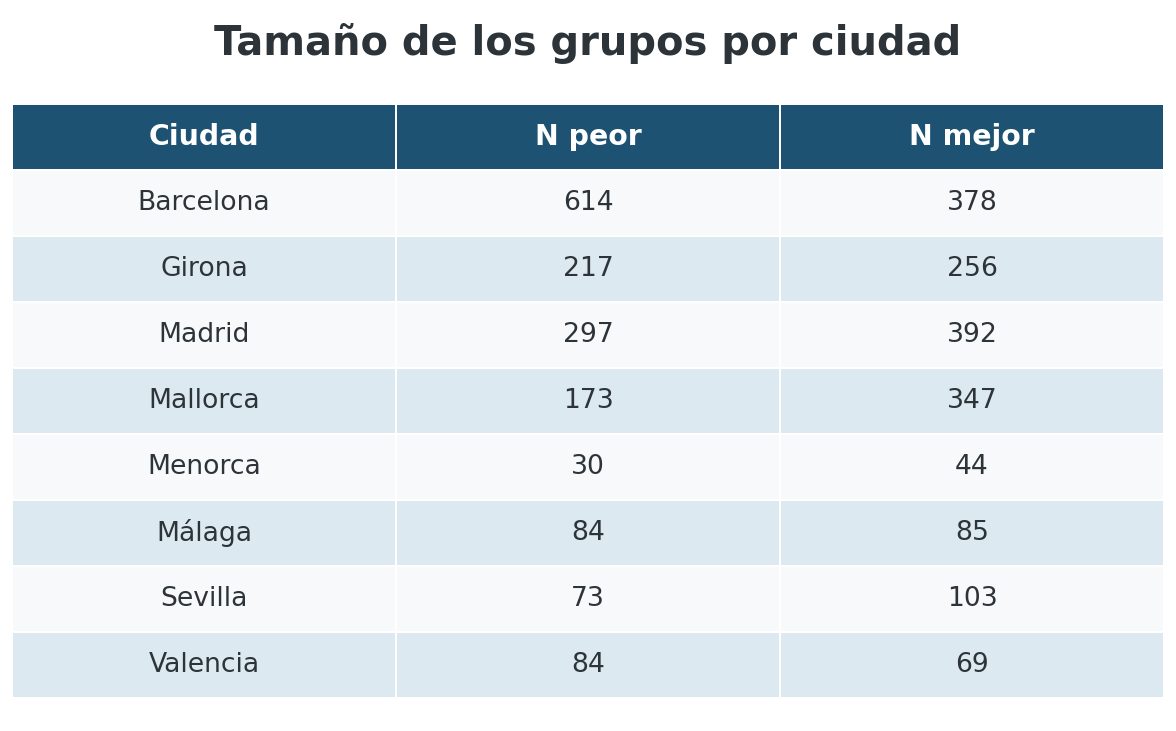

Ciudades incluidas: 8 de 8


In [22]:
MIN_GROUP_SIZE = 30

city_group_counts = (
    df_extremes
    .groupby(
        [
            "city",
            "grupo_valoracion",
        ]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=GROUP_ORDER)
)

eligible_cities = city_group_counts[
    (
        city_group_counts["Mejor valorados"]
        >= MIN_GROUP_SIZE
    )
    & (
        city_group_counts["Peor valorados"]
        >= MIN_GROUP_SIZE
    )
].index.tolist()

city_group_table = (
    city_group_counts
    .reset_index()
    .rename(
        columns={
            "city": "Ciudad",
            "Peor valorados": "N peor",
            "Mejor valorados": "N mejor",
        }
    )
)

graphic_table(
    city_group_table,
    "Tamaño de los grupos por ciudad",
    formats={
        "N peor": "{:,.0f}",
        "N mejor": "{:,.0f}",
    },
    width=10,
)

print(
    "Ciudades incluidas: "
    f"{len(eligible_cities)} de "
    f"{df_extremes['city'].nunique()}"
)

### Interpretación

Las ocho ciudades cumplen el mínimo de 30 alojamientos en cada grupo
y pueden incluirse en el análisis.

Sin embargo, los tamaños no son iguales.

Barcelona y Madrid tienen las muestras más grandes. Menorca presenta
la muestra más pequeña, con 30 alojamientos peor valorados y 44 mejor
valorados.

Por este motivo, los resultados de Menorca pueden ser menos estables
y deben interpretarse con más cautela.

### Comparación de las diferencias por ciudad

Primero, la tabla identifica qué aspecto presenta la mayor diferencia
en cada ciudad.

Después, el heatmap permite comparar la intensidad de las diferencias
entre ciudades y aspectos.

Finalmente, la tabla y el gráfico de consistencia territorial resumen
cuántas veces ocupa el primer lugar cada aspecto.

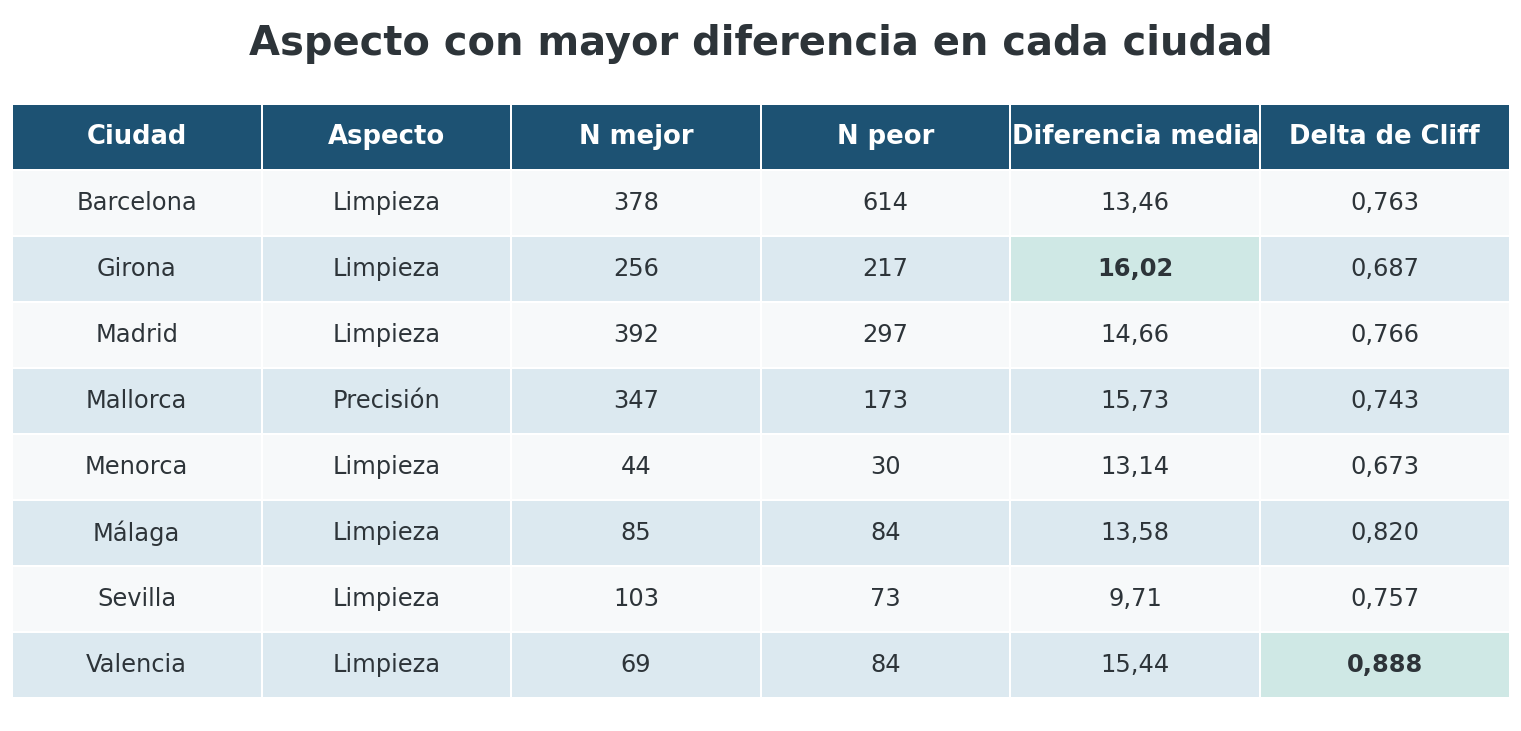

In [23]:
city_rows = []

for city in eligible_cities:
    city_data = df_extremes[
        df_extremes["city"] == city
    ]

    for aspect, column in ASPECT_COLUMNS_100.items():
        best_values = city_data.loc[
            (
                city_data["grupo_valoracion"]
                == "Mejor valorados"
            ),
            column,
        ]

        worst_values = city_data.loc[
            (
                city_data["grupo_valoracion"]
                == "Peor valorados"
            ),
            column,
        ]

        (
            _,
            _,
            cliff_delta,
        ) = mann_whitney_effect(
            best_values,
            worst_values,
        )

        city_rows.append(
            {
                "Ciudad": city,
                "Aspecto": aspect,
                "N mejor": len(best_values),
                "N peor": len(worst_values),
                "Media mejor": (
                    best_values.mean()
                ),
                "Media peor": (
                    worst_values.mean()
                ),
                "Diferencia media": (
                    best_values.mean()
                    - worst_values.mean()
                ),
                "Delta de Cliff": cliff_delta,
            }
        )

city_results = pd.DataFrame(city_rows)

city_winners = (
    city_results.loc[
        city_results
        .groupby("Ciudad")[
            "Diferencia media"
        ]
        .idxmax()
    ]
    .sort_values("Ciudad")
    .reset_index(drop=True)
)

graphic_table(
    city_winners[
        [
            "Ciudad",
            "Aspecto",
            "N mejor",
            "N peor",
            "Diferencia media",
            "Delta de Cliff",
        ]
    ],
    "Aspecto con mayor diferencia en cada ciudad",
    formats={
        "N mejor": "{:,.0f}",
        "N peor": "{:,.0f}",
        "Diferencia media": "{:.2f}",
        "Delta de Cliff": "{:.3f}",
    },
    highlight_max=[
        "Diferencia media",
        "Delta de Cliff",
    ],
    width=13,
)

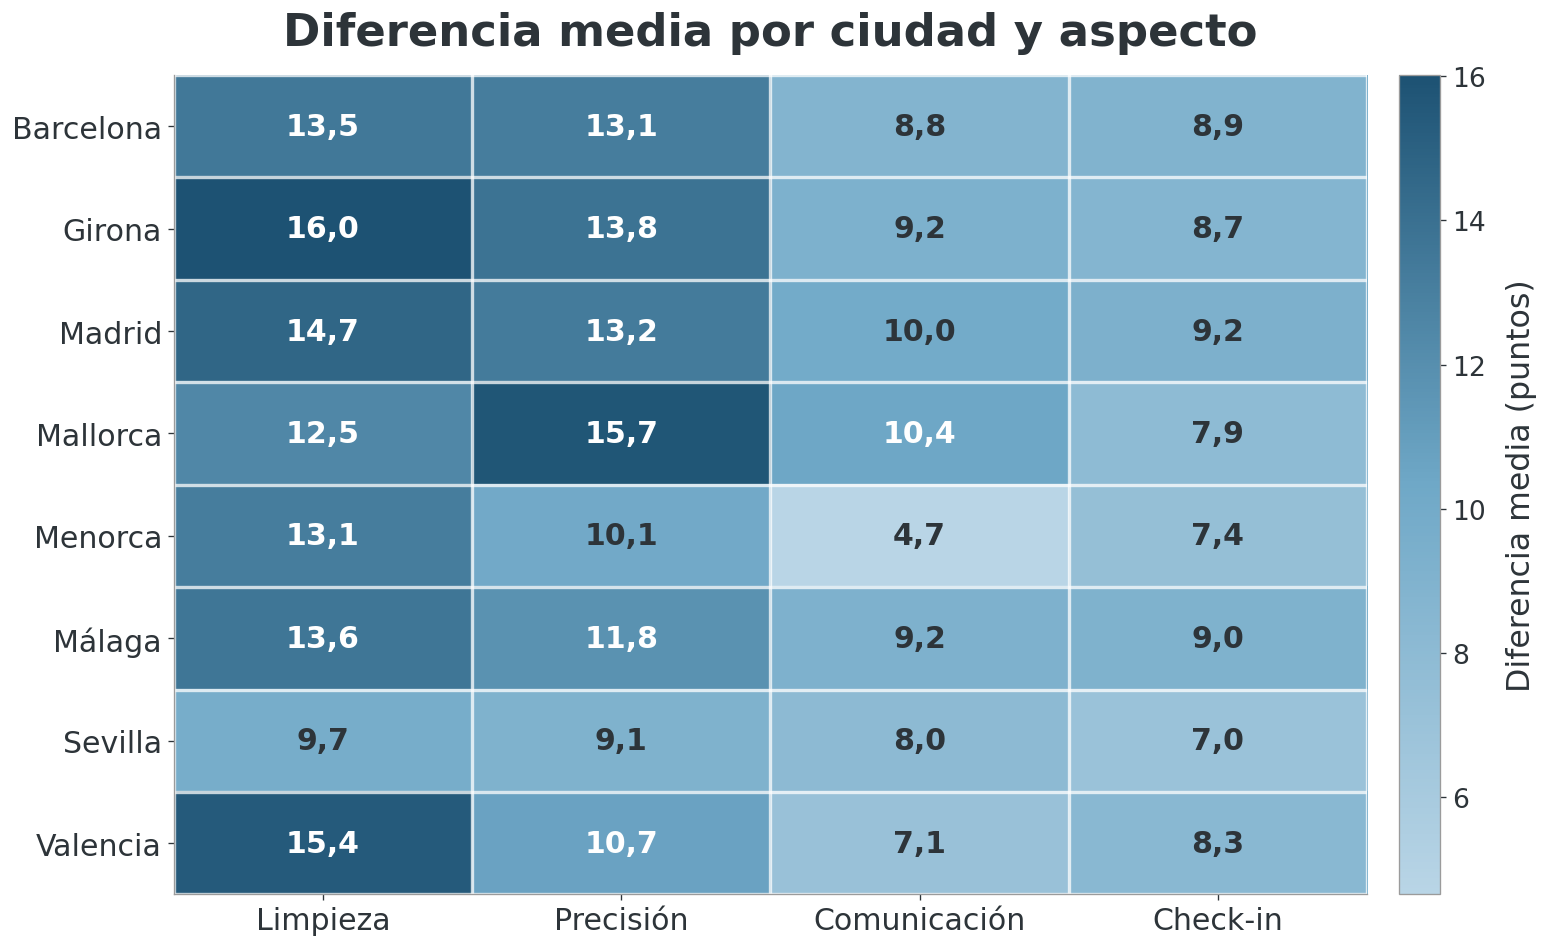

In [24]:
city_gap_matrix = (
    city_results.pivot(
        index="Ciudad",
        columns="Aspecto",
        values="Diferencia media",
    )
    .loc[eligible_cities]
)

# Orden coherente con el resultado principal

city_gap_matrix = city_gap_matrix[ASPECT_ORDER]

fig, ax = plt.subplots(
    figsize=(13, 8)
)

min_value = city_gap_matrix.to_numpy().min()
max_value = city_gap_matrix.to_numpy().max()

image = ax.imshow(
    city_gap_matrix,
    aspect="auto",cmap=BLUE_CMAP,vmin=min_value,vmax=max_value,
)

ax.set_title(
    "Diferencia media por ciudad y aspecto",fontsize=27,fontweight="bold",pad=18,
)

ax.set_xticks(
    np.arange(len(city_gap_matrix.columns))
)

ax.set_xticklabels(
    city_gap_matrix.columns,rotation=0,fontsize=18,
)

ax.set_yticks(
    np.arange(len(city_gap_matrix.index))
)

ax.set_yticklabels(
    city_gap_matrix.index,fontsize=18,
)

ax.set_xlabel("")
ax.set_ylabel("")

# Líneas blancas entre las celdas
ax.set_xticks(
    np.arange(
        -0.5,
        len(city_gap_matrix.columns),
        1,
    ),
    minor=True,
)

ax.set_yticks(
    np.arange(
        -0.5,
        len(city_gap_matrix.index),
        1,
    ),
    minor=True,
)

ax.grid(
    which="minor",
    color=WHITE,
    linestyle="-",
    linewidth=2,
)

ax.tick_params(
    which="minor",bottom=False,left=False,
)

# Punto medio para decidir el color del texto
color_threshold = (
    min_value + max_value
) / 2

for row_index in range(
    len(city_gap_matrix.index)
):
    for column_index in range(
        len(city_gap_matrix.columns)
    ):
        value = city_gap_matrix.iloc[
            row_index,
            column_index,
        ]

        text_color = (
            WHITE
            if value >= color_threshold
            else DARK
        )

        value_text = (
            f"{value:.1f}"
            .replace(".", ",")
        )

        ax.text(
            column_index,row_index,value_text,ha="center", va="center",fontsize=18,fontweight="bold",color=text_color,
        )

colorbar = fig.colorbar(
    image,ax=ax,pad=0.025,fraction=0.045,
)

colorbar.set_label(
    "Diferencia media (puntos)",fontsize=19,labelpad=12,
)

colorbar.ax.tick_params(
    labelsize=16,
)

plt.tight_layout()
plt.show()

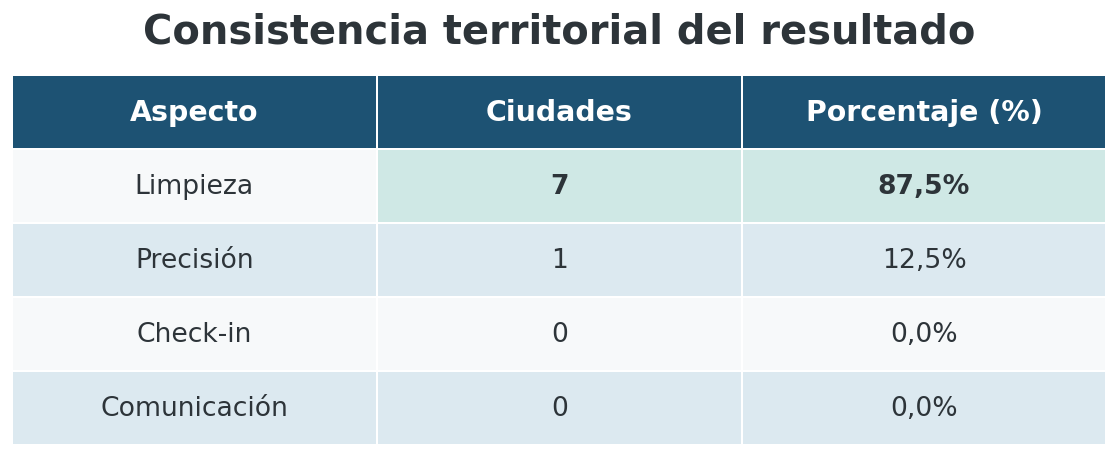

In [25]:
winner_summary = (
    city_winners["Aspecto"]
    .value_counts()
    .reindex(
        list(ASPECT_COLUMNS_100),
        fill_value=0,
    )
    .rename_axis("Aspecto")
    .reset_index(name="Ciudades")
)

winner_summary["Porcentaje (%)"] = (
    winner_summary["Ciudades"]
    / len(eligible_cities)
    * 100
)

winner_summary = (
    winner_summary
    .sort_values(
        ["Ciudades", "Aspecto"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

graphic_table(
    winner_summary,
    "Consistencia territorial del resultado",
    formats={
        "Ciudades": "{:.0f}",
        "Porcentaje (%)": "{:.1f}%",
    },
    highlight_max=[
        "Ciudades","Porcentaje (%)",
    ],
    width=9.5,
)

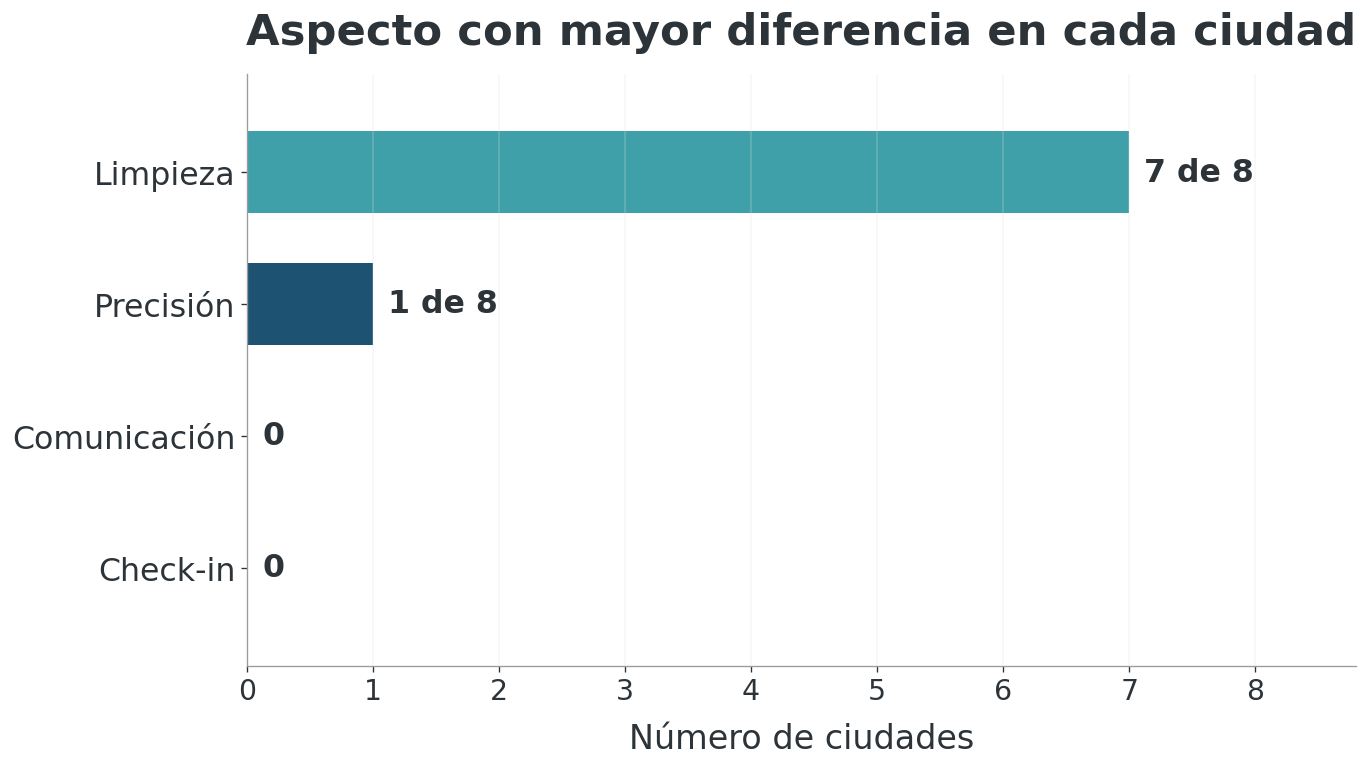

In [26]:
winner_plot = (
    winner_summary
    .sort_values(
        "Ciudades",
        ascending=True,
    )
    .copy()
)

total_cities = len(eligible_cities)
max_cities = winner_plot["Ciudades"].max()

fig, ax = plt.subplots(
    figsize=(11.5, 6.5)
)

colors = [
    TEAL
    if value == max_cities
    else NAVY
    if value > 0
    else LIGHT_GREY
    for value in winner_plot["Ciudades"]
]

bars = ax.barh(
    winner_plot["Aspecto"],winner_plot["Ciudades"],color=colors,height=0.62,
)

ax.set_title(
    "Aspecto con mayor diferencia en cada ciudad",fontsize=26,fontweight="bold",pad=18,
)

ax.set_xlabel(
    "Número de ciudades",fontsize=20,labelpad=10,
)

ax.set_ylabel("")

ax.set_xlim(
    0,
    total_cities + 0.8,
)

ax.set_xticks(
    range(0, total_cities + 1)
)

ax.tick_params(
    axis="x",labelsize=17,
)

ax.tick_params(
    axis="y",labelsize=19,
)

for bar, value in zip(
    bars,
    winner_plot["Ciudades"],
):
    label_x = (
        value + 0.12
        if value > 0
        else 0.12
    )

    label_text = (
        f"{int(value)} de {total_cities}"
        if value > 0
        else "0"
    )

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        label_text,va="center",ha="left",fontsize=19,fontweight="bold",color=DARK,
    )

ax.grid(
    axis="x",alpha=0.25,linewidth=1,
)

ax.grid(
    axis="y",visible=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.margins(y=0.12)

plt.tight_layout()
plt.show()

### Interpretación

Limpieza presenta la mayor diferencia en **7 de las 8 ciudades**,
es decir, en el **87,5 %** de los casos.

Precisión ocupa el primer lugar únicamente en Mallorca.

Las mayores diferencias de limpieza aparecen en:

- **Girona: 16,02 puntos**
- **Valencia: 15,44 puntos**
- **Madrid: 14,66 puntos**

Este resultado refuerza la prioridad de limpieza porque no depende
solo del resultado global.

Aun así, la diferencia de Girona debe interpretarse junto con su
menor cobertura de valoraciones completas.

## 9. Análisis de sensibilidad con umbrales fijos

La clasificación de los grupos puede influir en el resultado.

Para comprobarlo, repetimos el análisis con otros puntos de corte:

- **Peor valorados:** puntuación general inferior a 80.
- **Mejor valorados:** puntuación general igual o superior a 90.

Este análisis no sustituye el método principal con Q1 y Q3. Solo sirve
para comprobar si las prioridades cambian al utilizar otra definición.

Primero se revisan los tamaños y los resultados de los nuevos grupos.
Después se comparan directamente con el método principal basado en
Q1 y Q3.

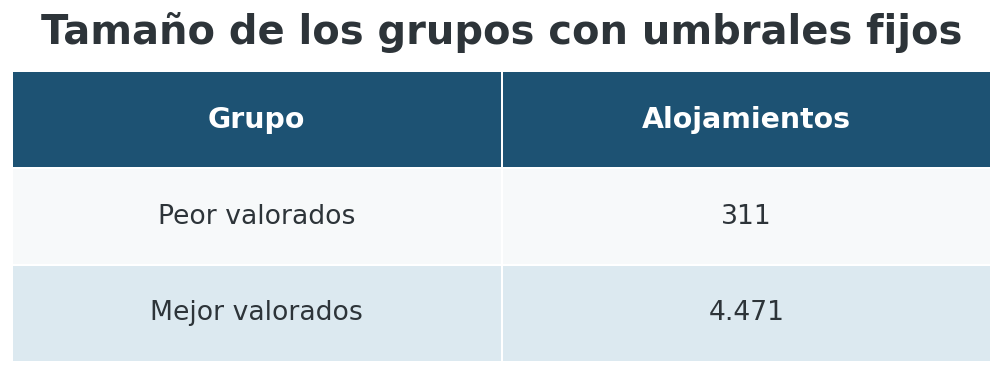

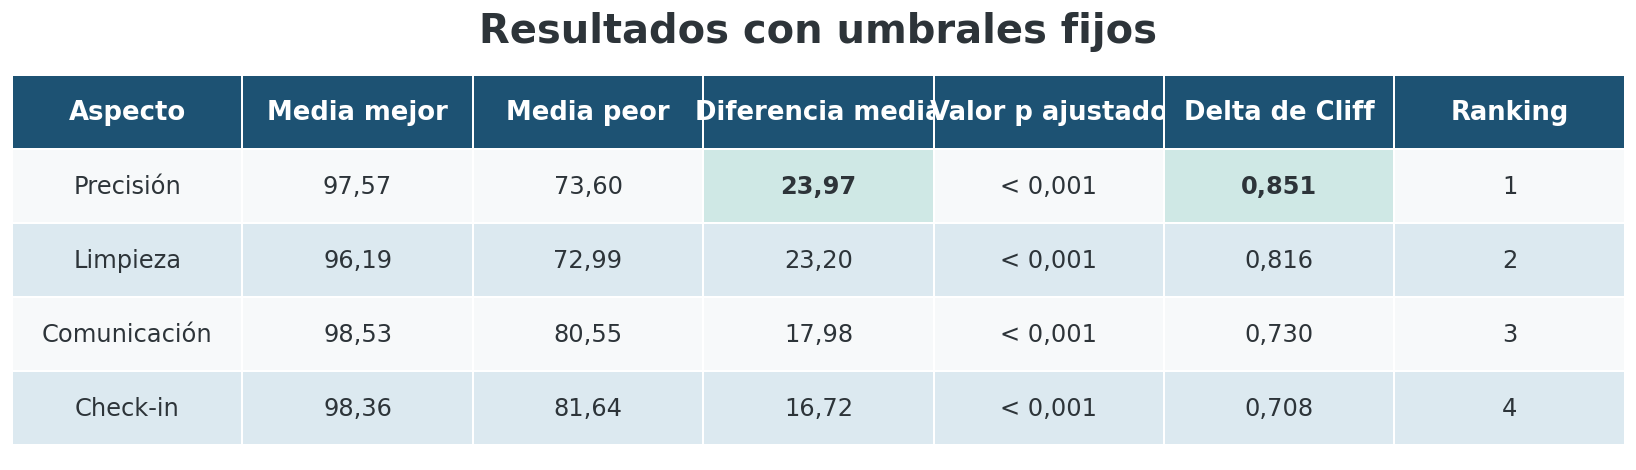

In [27]:
df_complete["grupo_umbral_fijo"] = np.select(
    [
        df_complete["rating_general_100"] < 80,
        df_complete["rating_general_100"] >= 90,
    ],
    [
        "Peor valorados",
        "Mejor valorados",
    ],
    default="Intermedios",
)

fixed_extremes = df_complete.loc[
    df_complete["grupo_umbral_fijo"].isin(GROUP_ORDER)
].copy()

fixed_group_counts = (
    fixed_extremes["grupo_umbral_fijo"]
    .value_counts()
    .reindex(GROUP_ORDER)
    .rename_axis("Grupo")
    .reset_index(name="Alojamientos")
)

graphic_table(
    fixed_group_counts,
    "Tamaño de los grupos con umbrales fijos",
    formats={"Alojamientos": "{:,.0f}"},
    width=8.5,
)

sensitivity_results = compare_aspects(
    fixed_extremes,
    "grupo_umbral_fijo",
)
sensitivity_results["Valor p ajustado"] = holm_adjust(
    sensitivity_results["Valor p"]
)
sensitivity_results = (
    sensitivity_results
    .sort_values("Diferencia media", ascending=False)
    .reset_index(drop=True)
)
sensitivity_results["Ranking"] = sensitivity_results.index + 1

sensitivity_display = sensitivity_results[
    [
        "Aspecto",
        "Media mejor",
        "Media peor",
        "Diferencia media",
        "Valor p ajustado",
        "Delta de Cliff",
        "Ranking",
    ]
].copy()
sensitivity_display["Valor p ajustado"] = (
    sensitivity_display["Valor p ajustado"].map(p_value_label)
)

graphic_table(
    sensitivity_display,
    "Resultados con umbrales fijos",
    formats={
        "Media mejor": "{:.2f}",
        "Media peor": "{:.2f}",
        "Diferencia media": "{:.2f}",
        "Delta de Cliff": "{:.3f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=["Diferencia media", "Delta de Cliff"],
    width=14,
)

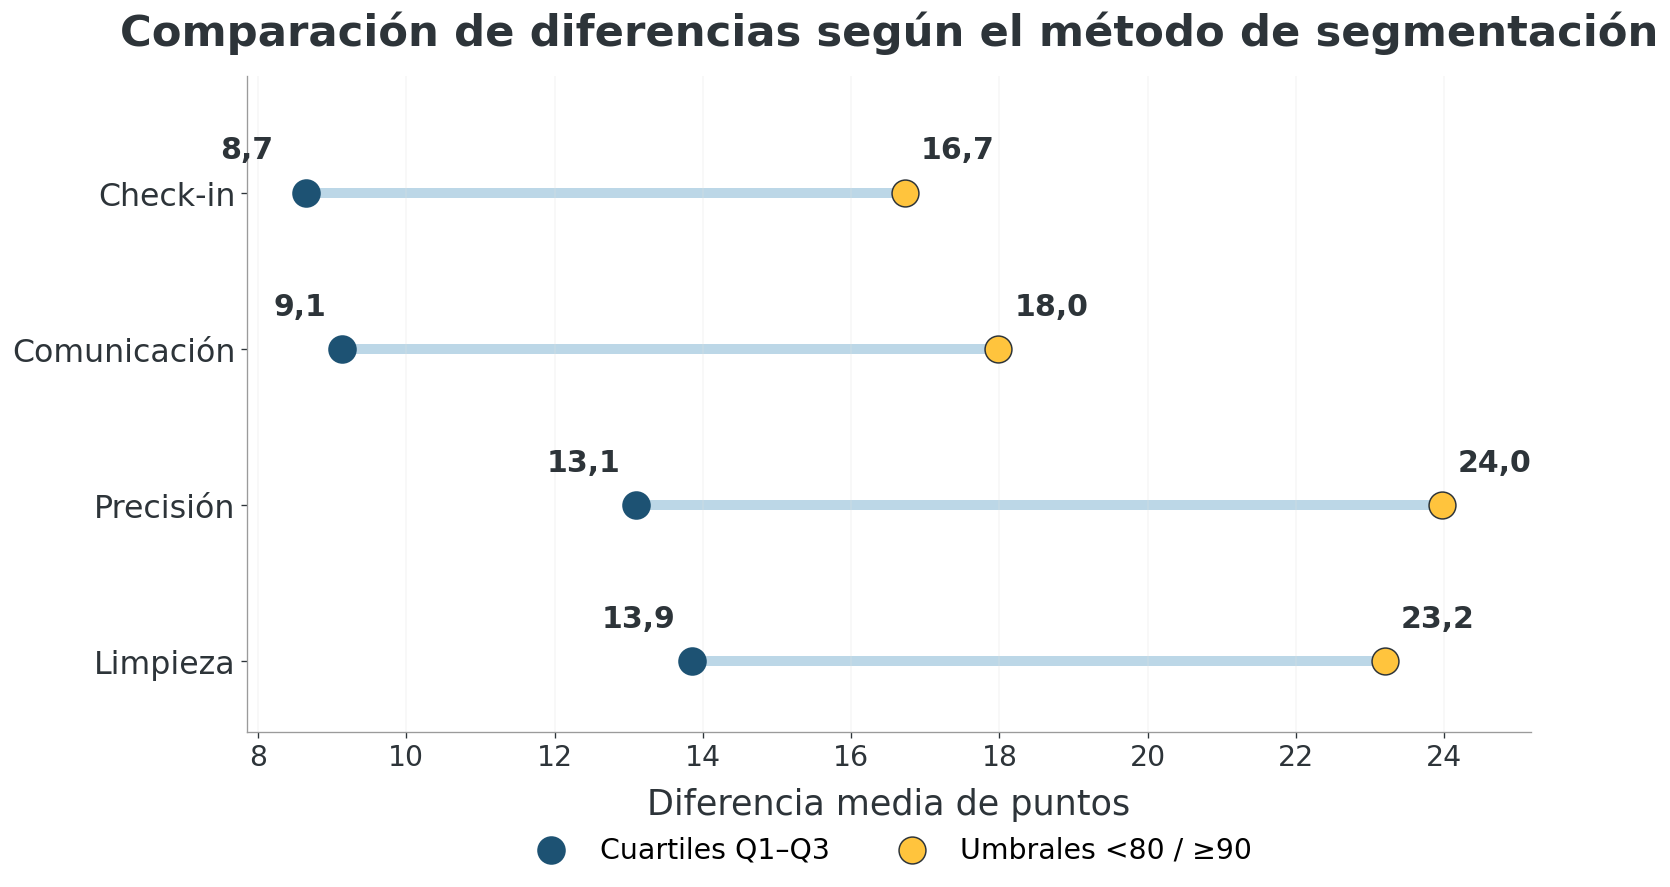

In [28]:
comparison_ranking = (
    gap_results[
        [
            "Aspecto","Diferencia de medias",
        ]
    ]
    .rename(
        columns={
            "Diferencia de medias":"Cuartiles Q1–Q3"
        }
    )
    .merge(
        sensitivity_results[
            [
                "Aspecto","Diferencia media",
            ]
        ].rename(
            columns={
                "Diferencia media":"Umbrales <80 / ≥90"
            }
        ),
        on="Aspecto",how="left",
    )
    .set_index("Aspecto")
)

# Orden coherente con la narrativa principal

comparison_ranking = comparison_ranking.loc[ASPECT_ORDER]

fig, ax = plt.subplots(figsize=(13, 7.5))

y_positions = np.arange(len(comparison_ranking))

for y_position, (aspect, row) in enumerate(
    comparison_ranking.iterrows()
):
    first_value = row["Cuartiles Q1–Q3"]
    second_value = row["Umbrales <80 / ≥90"]

    # Línea de unión
    ax.plot(
        [first_value, second_value],[y_position, y_position],color=LIGHT_BLUE,linewidth=6,alpha=0.95,zorder=1,
    )

    # Punto método 1
    ax.scatter(
        first_value,y_position,color=NAVY,s=260,
        label=(
            "Cuartiles Q1–Q3"
            if y_position == 0
            else None
        ),
        zorder=3,
    )

    # Punto método 2
    ax.scatter(
        second_value,y_position,color=YELLOW,edgecolor=DARK,linewidth=0.9,s=260,
        label=(
            "Umbrales <80 / ≥90"
            if y_position == 0
            else None
        ),
        zorder=3,
    )

    # Etiqueta izquierda
    first_text = (
        f"{first_value:.1f}"
        .replace(".", ",")
    )

    
    first_label_offset = (
        0.45
        if aspect == "Check-in"
        else 0.22
    )

    ax.text(
        first_value - first_label_offset,
        y_position + 0.18,
        first_text,
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        color=DARK,
    )

    # Etiqueta derecha
    second_text = (
        f"{second_value:.1f}"
        .replace(".", ",")
    )

    ax.text(
        second_value + 0.22,
        y_position + 0.18,
        second_text,ha="left",va="bottom",fontsize=18,fontweight="bold",color=DARK,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(
    comparison_ranking.index,
    fontsize=19,
)

ax.set_title(
    "Comparación de diferencias según el método de segmentación",fontsize=26,fontweight="bold",pad=18,
)

ax.set_xlabel(
    "Diferencia media de puntos",fontsize=21,labelpad=10,
)

ax.set_ylabel("")

# Márgenes para que no se corten etiquetas
x_min = comparison_ranking.min().min()
x_max = comparison_ranking.max().max()

ax.set_xlim(x_min - 0.8, x_max + 1.2)
ax.set_ylim(-0.45, len(comparison_ranking) - 0.25)

ax.tick_params(
    axis="x",labelsize=17,
)

ax.tick_params(
    axis="y",labelsize=19,
)

ax.grid(
    axis="x",alpha=0.25,linewidth=1,
)

ax.grid(
    axis="y",visible=False,
)

ax.legend(
    frameon=False,ncol=2,loc="upper center",bbox_to_anchor=(0.5, -0.12),fontsize=17,handlelength=1.8,columnspacing=2.0,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

### Interpretación

Con los umbrales alternativos se obtienen:

- **311 alojamientos peor valorados**
- **4.471 alojamientos mejor valorados**

En este caso los grupos están mucho más desequilibrados, por lo que
el resultado se utiliza solo como comprobación.

El nuevo ranking es:

1. **Precisión:** 23,97 puntos.
2. **Limpieza:** 23,20 puntos.
3. **Comunicación:** 17,98 puntos.
4. **Check-in:** 16,72 puntos.

El orden de limpieza y precisión cambia, pero los dos aspectos siguen
ocupando las primeras posiciones.

Por tanto, la prioridad exacta depende en parte de cómo se definan
los grupos, aunque limpieza y precisión se mantienen como los
principales puntos de mejora.

### Sensibilidad con un mínimo de reseñas

Las puntuaciones basadas en muy pocas reseñas pueden ser menos
estables. Por este motivo, repetimos la comparación utilizando solo
alojamientos con al menos **5 reseñas**.

Se mantienen los mismos puntos de corte Q1 y Q3 del análisis principal
para comprobar si cambian las prioridades.

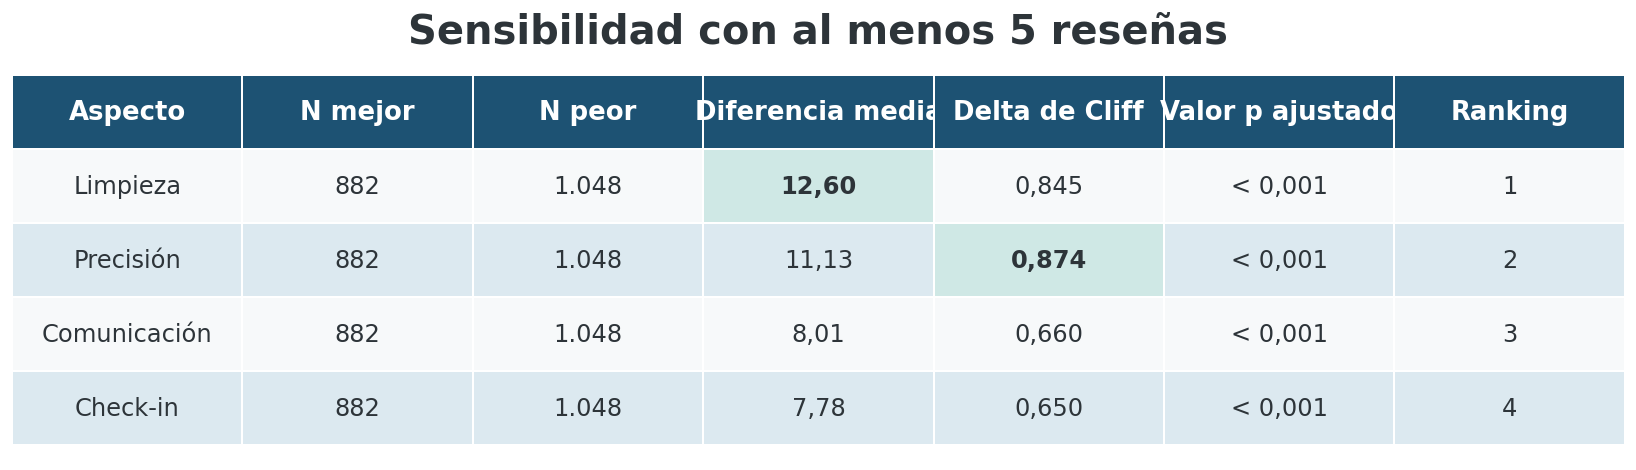

In [29]:
MIN_REVIEWS = 5

df_reviews_min = df_complete.loc[
    df_complete["number_of_reviews"] >= MIN_REVIEWS
].copy()

df_reviews_min["grupo_valoracion"] = np.select(
    [
        df_reviews_min["rating_general_100"] <= q1,
        df_reviews_min["rating_general_100"] >= q3,
    ],
    [
        "Peor valorados",
        "Mejor valorados",
    ],
    default="Intermedios",
)

df_reviews_extremes = df_reviews_min.loc[
    df_reviews_min["grupo_valoracion"].isin(GROUP_ORDER)
].copy()

review_sensitivity = compare_aspects(
    df_reviews_extremes,
    "grupo_valoracion",
)
review_sensitivity["Valor p ajustado"] = holm_adjust(
    review_sensitivity["Valor p"]
)
review_sensitivity = (
    review_sensitivity
    .sort_values("Diferencia media", ascending=False)
    .reset_index(drop=True)
)
review_sensitivity["Ranking"] = review_sensitivity.index + 1

review_sensitivity_display = review_sensitivity[
    [
        "Aspecto",
        "N mejor",
        "N peor",
        "Diferencia media",
        "Delta de Cliff",
        "Valor p ajustado",
        "Ranking",
    ]
].copy()
review_sensitivity_display["Valor p ajustado"] = (
    review_sensitivity_display["Valor p ajustado"].map(p_value_label)
)

graphic_table(
    review_sensitivity_display,
    "Sensibilidad con al menos 5 reseñas",
    formats={
        "N mejor": "{:,.0f}",
        "N peor": "{:,.0f}",
        "Diferencia media": "{:.2f}",
        "Delta de Cliff": "{:.3f}",
        "Ranking": "{:.0f}",
    },
    highlight_max=["Diferencia media", "Delta de Cliff"],
    width=14,
)

### Interpretación

Al exigir un mínimo de 5 reseñas, **limpieza** mantiene la mayor
diferencia media y **precisión** continúa presentando el mayor delta
de Cliff.

El resultado principal se mantiene incluso cuando se excluyen las
puntuaciones basadas en muy pocas reseñas. Esto refuerza la estabilidad
de las dos prioridades principales.

## 10. Riesgos potenciales de sesgo y limitaciones

Durante el análisis revisamos los posibles sesgos tomando como
referencia el [Catalogue of Bias](https://catalogofbias.org/biases/).

Los siguientes puntos son riesgos posibles o limitaciones. No significa
que todos estén demostrados con los datos disponibles.

### Sesgo de selección

El análisis utiliza solo alojamientos con la puntuación general y los
cuatro aspectos completos.

Si los alojamientos excluidos tienen características diferentes, la
muestra final puede no representar exactamente al dataset completo.

Para revisarlo comparamos:

- La cobertura total y por ciudad.
- El perfil de los casos completos e incompletos.
- El precio, la capacidad y el número de reseñas.

### Sesgo de no respuesta

Los huéspedes que dejan una reseña pueden ser diferentes de quienes
no la dejan. Por ejemplo, una experiencia muy positiva o muy negativa
puede aumentar la probabilidad de escribir una valoración.

El dataset no contiene información sobre los huéspedes que decidieron
no valorar. Por tanto, este riesgo no puede comprobarse directamente.

### Sesgo de información y medición

Las puntuaciones son subjetivas y pueden depender de las expectativas
de cada huésped.

Además, muchas valoraciones están concentradas en 100, lo que reduce
la capacidad de distinguir entre alojamientos muy bien valorados.

Para limitar este problema utilizamos:

- Medias y medianas.
- Mann–Whitney U.
- Delta de Cliff.
- Revisión de las distribuciones.

### Sensibilidad a la clasificación por puntos de corte

Los grupos mejor y peor valorados dependen de los puntos de corte
elegidos.

Los empates en Q1 y Q3 también hacen que los grupos sean algo mayores
del 25 %.

Para comprobar la estabilidad del resultado repetimos el análisis con
umbrales alternativos y mostramos el tamaño de todos los grupos.

### Confusión

Otras variables pueden influir en las diferencias observadas, por
ejemplo:

- Ciudad.
- Precio.
- Tipo de alojamiento.
- Capacidad.
- Número de reseñas.
- Fecha del snapshot.

La comparación por ciudad reduce una parte de este riesgo, pero no
controla todos los factores al mismo tiempo.

Por eso hablamos de diferencias observadas y no de efectos causales.

### Relación entre el rating general y los aspectos

La puntuación general y los cuatro aspectos forman parte del mismo
sistema de valoración.

Por tanto, es normal que estén relacionados. El análisis permite ver
qué aspectos separan mejor a los dos grupos, pero no demuestra que
cambiar uno de ellos aumente automáticamente el rating general.

### Sesgo de confirmación y data-dredging

El método principal se definió antes de revisar los resultados. El
análisis con umbrales alternativos se presenta como una comprobación
secundaria y no sustituye al método principal.

### Reporting bias

Para evitar mostrar únicamente el resultado más favorable:

- Se presentan los cuatro aspectos.
- Se muestran los valores p ajustados.
- Se informa del tamaño del efecto.
- Se incluyen los análisis de sensibilidad aunque cambie el ranking.

### Diferencias temporales

Los últimos snapshots no pertenecen todos al mismo año. Por tanto,
los alojamientos no están observados exactamente en el mismo momento.

La fecha se mantiene en el dataset y esta limitación se tiene en cuenta
al interpretar los resultados.

### Comparaciones múltiples

Se realizan cuatro pruebas estadísticas, una por aspecto.

Para reducir el riesgo de falsos positivos se utiliza la corrección
de Holm. Se trata de un riesgo estadístico y no de una categoría de
sesgo independiente.


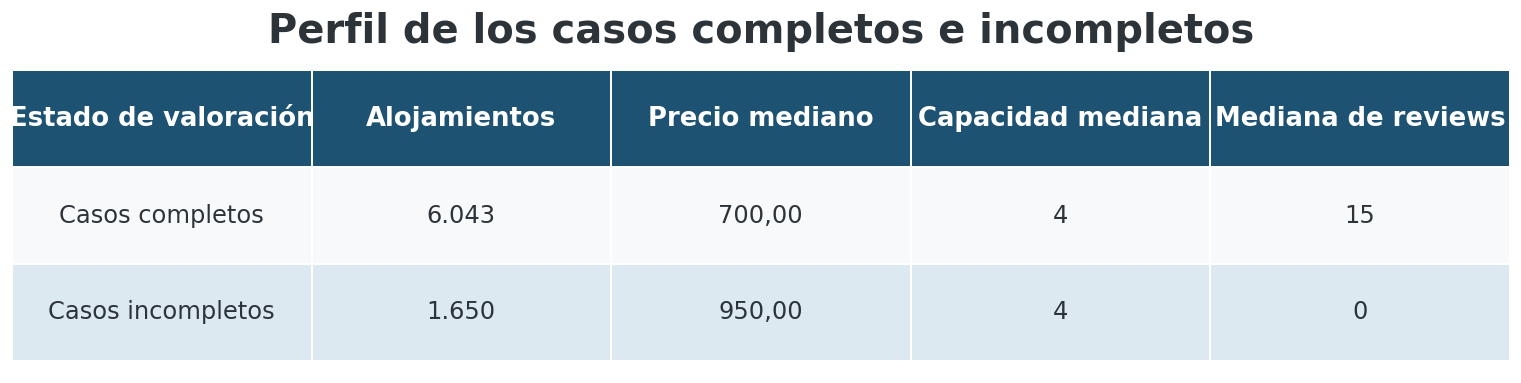

In [30]:
df_bias_profile = df.copy()

df_bias_profile["Estado de valoración"] = np.where(
    df_bias_profile[complete_columns].notna().all(axis=1),
    "Casos completos",
    "Casos incompletos",
)

bias_profile = (
    df_bias_profile
    .groupby("Estado de valoración", as_index=False)
    .agg(
        Alojamientos=("apartment_id", "nunique"),
        Precio_mediano=("price_€", "median"),
        Capacidad_mediana=("accommodates", "median"),
        Reviews_mediana=("number_of_reviews", "median"),
    )
    .rename(
        columns={
            "Precio_mediano": "Precio mediano",
            "Capacidad_mediana": "Capacidad mediana",
            "Reviews_mediana": "Mediana de reviews",
        }
    )
)

graphic_table(
    bias_profile,
    "Perfil de los casos completos e incompletos",
    formats={
        "Alojamientos": "{:,.0f}",
        "Precio mediano": "{:.2f}",
        "Capacidad mediana": "{:.0f}",
        "Mediana de reviews": "{:.0f}",
    },
    width=13,
)

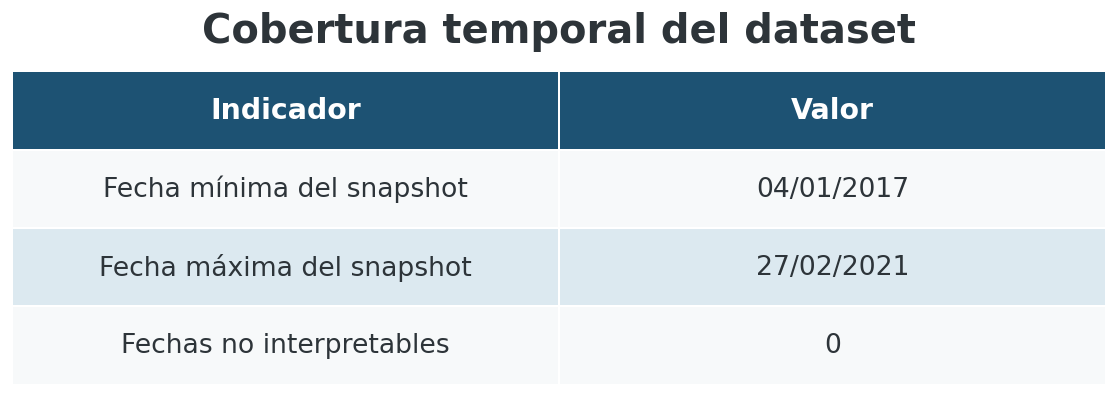

In [31]:
df["insert_date_parsed"] = pd.to_datetime(
    df["insert_date"],
    errors="coerce",
)

temporal_summary = pd.DataFrame(
    {
        "Indicador": [
            "Fecha mínima del snapshot",
            "Fecha máxima del snapshot",
            "Fechas no interpretables",
        ],
        "Valor": [
            df["insert_date_parsed"]
            .min()
            .strftime("%d/%m/%Y"),
            df["insert_date_parsed"]
            .max()
            .strftime("%d/%m/%Y"),
            df["insert_date_parsed"]
            .isna()
            .sum(),
        ],
    }
)

graphic_table(
    temporal_summary,
    "Cobertura temporal del dataset",
    width=9.5,
)

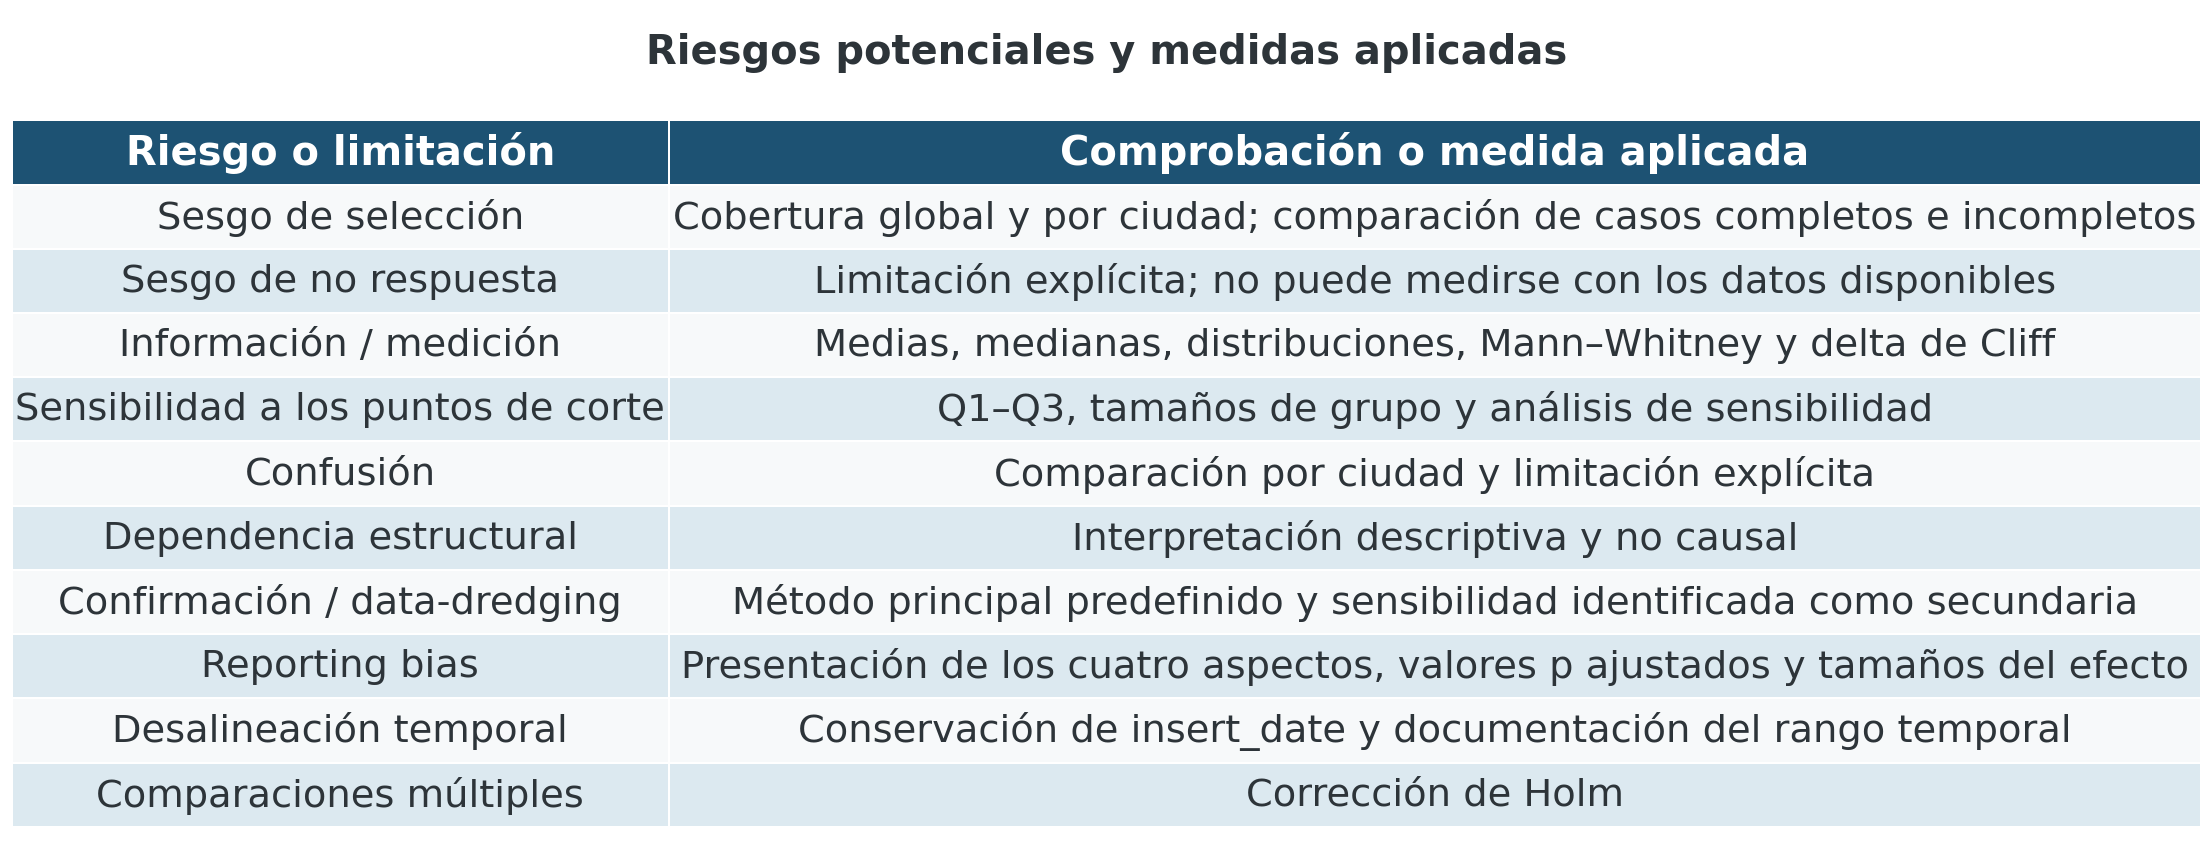

In [32]:
bias_register = pd.DataFrame(
    {
        "Riesgo o limitación": [
            "Sesgo de selección",
            "Sesgo de no respuesta",
            "Información / medición",
            "Sensibilidad a los puntos de corte",
            "Confusión",
            "Dependencia estructural",
            "Confirmación / data-dredging",
            "Reporting bias",
            "Desalineación temporal",
            "Comparaciones múltiples",
        ],
        "Comprobación o medida aplicada": [
            (
                "Cobertura global y por ciudad; "
                "comparación de casos completos e incompletos"
            ),
            (
                "Limitación explícita; no puede medirse "
                "con los datos disponibles"
            ),
            (
                "Medias, medianas, distribuciones, "
                "Mann–Whitney y delta de Cliff"
            ),
            (
                "Q1–Q3, tamaños de grupo y "
                "análisis de sensibilidad"
            ),
            "Comparación por ciudad y limitación explícita",
            "Interpretación descriptiva y no causal",
            (
                "Método principal predefinido y "
                "sensibilidad identificada como secundaria"
            ),
            (
                "Presentación de los cuatro aspectos, "
                "valores p ajustados y tamaños del efecto"
            ),
            (
                "Conservación de insert_date y "
                "documentación del rango temporal"
            ),
            "Corrección de Holm",
        ],
    }
)

graphic_table(
    bias_register,
    "Riesgos potenciales y medidas aplicadas",
    width=19,
    font_size=23,
    column_widths=[0.30, 0.70],
)

### Interpretación

Los casos completos e incompletos no tienen exactamente el mismo
perfil.

Los casos completos presentan:

- Una mediana de **15 reseñas**.
- Un precio mediano de **700 €**.
- Una capacidad mediana de **4 personas**.

Los casos incompletos presentan:

- Una mediana de **0 reseñas**.
- Un precio mediano de **950 €**.
- La misma capacidad mediana de **4 personas**.

Esto muestra que la muestra con valoraciones completas no es
exactamente igual al dataset total. Por tanto, existe un posible
riesgo de selección.

Además, los snapshots van desde enero de 2017 hasta febrero de 2021.
Los alojamientos no representan un único momento del mercado.

Por estas razones, los resultados se interpretan como asociaciones
dentro de la muestra analizada y no como relaciones causales.

## 11. Respuesta y recomendación de negocio

In [33]:
main_aspect = gap_results.iloc[0]["Aspecto"]
main_gap = gap_results.iloc[0]["Diferencia de medias"]
main_best_mean = gap_results.iloc[0]["Media mejor valorados"]
main_worst_mean = gap_results.iloc[0]["Media peor valorados"]

main_test = (
    test_results
    .set_index("Aspecto")
    .loc[main_aspect]
)
main_adjusted_p = main_test["Valor p ajustado"]
main_effect = main_test["Tamaño del efecto"]
main_delta = main_test["Delta de Cliff"]

effect_leader = (
    test_results
    .set_index("Aspecto")["Delta de Cliff"]
    .abs()
    .idxmax()
)
effect_leader_value = (
    test_results
    .set_index("Aspecto")
    .loc[effect_leader, "Delta de Cliff"]
)

territorial_row = winner_summary.loc[
    winner_summary["Ciudades"].idxmax()
]
territorial_leader = territorial_row["Aspecto"]
territorial_cities = int(territorial_row["Ciudades"])
territorial_percentage = territorial_row["Porcentaje (%)"]
sensitivity_leader = sensitivity_results.iloc[0]["Aspecto"]

review_gap_leader = review_sensitivity.iloc[0]["Aspecto"]
review_effect_leader = (
    review_sensitivity
    .set_index("Aspecto")["Delta de Cliff"]
    .abs()
    .idxmax()
)

action_map = {
    "Limpieza": (
        "reforzar los protocolos de limpieza, utilizar checklists "
        "por estancia y realizar controles de calidad"
    ),
    "Precisión": (
        "revisar periódicamente las descripciones, los servicios, "
        "las fotografías y las normas publicadas"
    ),
    "Check-in": (
        "estandarizar las instrucciones, confirmar la información "
        "antes de la llegada y simplificar el acceso"
    ),
    "Comunicación": (
        "definir tiempos máximos de respuesta, utilizar plantillas "
        "y realizar un seguimiento proactivo"
    ),
}

significance_text = (
    "estadísticamente significativa"
    if main_adjusted_p < 0.05
    else "no estadísticamente significativa"
)
recommendation = action_map[main_aspect]

sample_size_text = format_es(len(df_complete), 0, thousands=True)
main_gap_text = format_es(main_gap, 2)
main_best_text = format_es(main_best_mean, 2)
main_worst_text = format_es(main_worst_mean, 2)
main_delta_text = format_es(main_delta, 3)
territorial_text = format_es(territorial_percentage, 1)
effect_value_text = format_es(abs(effect_leader_value), 3)

display(
    Markdown(
        f"""
### Respuesta a la pregunta de negocio

La muestra analítica incluye **{sample_size_text} alojamientos** con
la puntuación general y los cuatro aspectos completos.

Los puntos de corte principales son **Q1 = {q1:.0f}** y
**Q3 = {q3:.0f}**.

El aspecto con la mayor diferencia media entre los alojamientos mejor
y peor valorados es **{main_aspect}**, con una diferencia de
**{main_gap_text} puntos**.

Los alojamientos mejor valorados tienen una media de
**{main_best_text}**, frente a **{main_worst_text}** en los peor
valorados.

La diferencia es **{significance_text}** después de aplicar la
corrección de Holm (`p ajustado {p_value_label(main_adjusted_p)}`) y
presenta un tamaño del efecto **{main_effect.lower()}**
(`δ = {main_delta_text}`).

Además, **{territorial_leader}** ocupa el primer lugar en
**{territorial_cities} de {len(eligible_cities)} ciudades**
(**{territorial_text} %**).

### Recomendación principal

Se recomienda **{recommendation}** en los alojamientos con menor
valoración general.

### Matices para la interpretación

Los resultados no señalan exactamente al mismo aspecto según el
indicador utilizado:

- **{main_aspect}** presenta la mayor diferencia media.
- **{effect_leader}** presenta el mayor delta de Cliff
  (`|δ| = {effect_value_text}`).
- Con los umbrales alternativos, el primer lugar corresponde a
  **{sensitivity_leader}**.
- Al exigir un mínimo de 5 reseñas, lideran **{review_gap_leader}**
  en diferencia media y **{review_effect_leader}** en tamaño del efecto.

Esto no es una contradicción. Cada indicador mide una parte diferente
del resultado.

Se prioriza **{main_aspect}** porque presenta la mayor brecha media y
la mayor consistencia entre ciudades. **{effect_leader}** se mantiene
como segunda prioridad porque separa con más fuerza a los grupos y
lidera el análisis con umbrales alternativos.
"""
    )
)



### Respuesta a la pregunta de negocio

La muestra analítica incluye **6.043 alojamientos** con
la puntuación general y los cuatro aspectos completos.

Los puntos de corte principales son **Q1 = 89** y
**Q3 = 98**.

El aspecto con la mayor diferencia media entre los alojamientos mejor
y peor valorados es **Limpieza**, con una diferencia de
**13,86 puntos**.

Los alojamientos mejor valorados tienen una media de
**98,32**, frente a **84,46** en los peor
valorados.

La diferencia es **estadísticamente significativa** después de aplicar la
corrección de Holm (`p ajustado < 0,001`) y
presenta un tamaño del efecto **grande**
(`δ = 0,744`).

Además, **Limpieza** ocupa el primer lugar en
**7 de 8 ciudades**
(**87,5 %**).

### Recomendación principal

Se recomienda **reforzar los protocolos de limpieza, utilizar checklists por estancia y realizar controles de calidad** en los alojamientos con menor
valoración general.

### Matices para la interpretación

Los resultados no señalan exactamente al mismo aspecto según el
indicador utilizado:

- **Limpieza** presenta la mayor diferencia media.
- **Precisión** presenta el mayor delta de Cliff
  (`|δ| = 0,777`).
- Con los umbrales alternativos, el primer lugar corresponde a
  **Precisión**.
- Al exigir un mínimo de 5 reseñas, lideran **Limpieza**
  en diferencia media y **Precisión** en tamaño del efecto.

Esto no es una contradicción. Cada indicador mide una parte diferente
del resultado.

Se prioriza **Limpieza** porque presenta la mayor brecha media y
la mayor consistencia entre ciudades. **Precisión** se mantiene
como segunda prioridad porque separa con más fuerza a los grupos y
lidera el análisis con umbrales alternativos.


### Alcance de la conclusión

Los resultados representan a los alojamientos de las ocho ciudades
que tienen la puntuación general y los cuatro aspectos completos.

No representan automáticamente:

- Los alojamientos sin valoraciones.
- Los huéspedes que no dejaron una reseña.
- Otras ciudades no incluidas en el dataset.
- Otros periodos diferentes a los observados.

El análisis principal también deja fuera al grupo intermedio, que
representa el **46,28 %** de la muestra.

Las diferencias encontradas ayudan a identificar prioridades, pero
no demuestran que mejorar un aspecto produzca por sí solo un aumento
del rating general.

## 12. Próximos pasos

Para reforzar este análisis se podría:

1. Probar otros mínimos de reseñas, por ejemplo 10 o 20, para
   comprobar hasta qué punto se mantiene el resultado.
2. Calcular intervalos de confianza mediante bootstrap.
3. Aplicar un modelo que controle ciudad, precio, tipo de alojamiento,
   capacidad y número de reseñas.
4. Analizar el texto de las reseñas para entender mejor los problemas
   relacionados con limpieza y precisión.
5. Repetir el análisis con datos más recientes.
6. Medir los resultados antes y después de aplicar las mejoras.

## Referencias de trabajo

- `Guió desafiament Nº2`.
- `Justificacion_Tecnica_Experiencia_Cliente_06_07_2026_FINAL.docx`.
- `Data_Understanding_06_07_2026`.
- `EDA_06_07_2026`.
- `Data_Cleaning_06_07_2026`.
- `Instrucciones para Analistas de Datos Junior`.
- `Onboarding_alojamientos`.
- *Catalogue of Bias*:
  - [Selection bias](https://catalogofbias.org/biases/selection-bias/),
  - [Non-response bias](https://catalogofbias.org/biases/non-response-bias/),
  - [Information bias](https://catalogofbias.org/biases/information-bias/),
  - [Confounding](https://catalogofbias.org/biases/confounding/),
  - [Reporting biases](https://catalogofbias.org/biases/reporting-biases/),
  - [Confirmation bias](https://catalogofbias.org/biases/confirmation-bias/) y
  - [Chronological bias](https://catalogofbias.org/biases/chronological-bias/).